# Notebook 6 — statistical tests and logit models

Running non-parametric tests, computing correlations, estimating logit specifications, and performing robustness and heterogeneity checks.

**Steps performed:**
1. Creating lagged predictors (t−1)
2. Mann-Whitney U tests for all financial indicators
3. Spearman correlation matrix on lagged variables
4. Point-biserial correlation and univariate logit
5. Main logit models Model-1–Model-5 (setup, VIF, estimation, coefficients table)
6. Alternative specifications Alternative-1–Alternative-5 (profitability, liquidity, activity groups)
7. Final model selection from Alternative-2_ROA significant predictors
8. Robustness checks R1–R5
9. Heterogeneity: crisis interactions, subperiod analysis
10. Regional models
11. Sectoral models
12. ICR supplementary models (Energy and Mining)

**Main dependent variable:** Y3 — Increasing Credit (`Y3_Increasing_Credit`)  
**Input:** `df_cleaned.csv` from Notebook 1.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from scipy.stats.mstats import winsorize
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

## 0. Loading data and reconstructing variables

In [2]:
df = pd.read_csv('df_cleaned.csv', sep=';', encoding='utf-8', low_memory=False)
print('Dataset shape:', df.shape)

Dataset shape: (81062, 167)


In [3]:
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams.update({
    'figure.facecolor': 'white', 'figure.dpi': 150,
    'font.family': 'serif', 'font.serif': ['Georgia', 'Times New Roman', 'DejaVu Serif'],
    'font.size': 11, 'axes.facecolor': 'white', 'axes.edgecolor': '#2c2c2c',
    'axes.linewidth': 0.8, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.titlepad': 14, 'axes.labelsize': 11, 'axes.labelcolor': '#2c2c2c',
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': '#e0e0e0', 'grid.linewidth': 0.6, 'grid.linestyle': '--',
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 10, 'legend.framealpha': 0.9, 'legend.edgecolor': '#cccccc',
    'savefig.dpi': 300, 'savefig.bbox': 'tight', 'savefig.facecolor': 'white',
})
COLORS = {
    'primary': '#2c5f8a', 'secondary': '#4a9aba', 'positive': '#3ab5a5',
    'negative': '#d9534f', 'neutral': '#95a5a6', 'accent': '#f0c060', 'light': '#ddeef7',
}

In [4]:
SECTOR_MAP = {
    'A': 'Agriculture', 'B': 'Mining', 'C': 'Manufacturing', 'D': 'Energy',
    'E': 'Water & Waste', 'F': 'Construction', 'G': 'Wholesale & Retail Trade',
    'H': 'Transportation', 'I': 'Accommodation & Food', 'J': 'Information & Communication',
    'K': 'Financial Services', 'L': 'Real Estate', 'M': 'Professional Services',
    'N': 'Administrative Services', 'O': 'Public Administration', 'P': 'Education',
    'Q': 'Health & Social Work', 'R': 'Arts & Entertainment', 'S': 'Other Services',
}
TOP_SECTORS  = ['Wholesale & Retail Trade', 'Manufacturing', 'Agriculture', 'Energy', 'Mining']
SECTOR_ORDER = ['Agriculture', 'Manufacturing', 'Wholesale & Retail Trade', 'Energy', 'Mining', 'Other']

FRONTLINE_2014 = ['Донецька область', 'Луганська область']
FRONTLINE_2022 = ['Харківська область', 'Запорізька область', 'Херсонська область',
                  'Миколаївська область', 'Чернігівська область', 'Сумська область']

MAIN_DEP_VAR = 'Y3_Increasing_Credit'
ALL_DEP_VARS = [
    ('Y1_Has_Credit',         'Y1: Has Credit'),
    ('Y2_Active_Credit_User', 'Y2: Active Credit User'),
    ('Y3_Increasing_Credit',  'Y3: Increasing Credit'),
]

FIN_COLS_LABELS = {
    'log_Total_Assets_w': 'log(Total Assets)', 'log_Net_Revenue_w': 'log(Net Revenue)',
    'EBIT_Margin_w': 'EBIT Margin', 'EBITDA_Margin_w': 'EBITDA Margin',
    'PBT_Margin_w': 'PBT Margin', 'ROA_w': 'ROA', 'GP_Margin_w': 'GP Margin',
    'Current_Ratio_w': 'Current Ratio', 'Quick_Ratio_w': 'Quick Ratio',
    'Cash_Ratio_w': 'Cash Ratio', 'Equity_Ratio_w': 'Equity Ratio',
    'NetDebt_to_EBITDA_w': 'Net Debt / EBITDA', 'Debt_to_Assets_w': 'Debt to Assets',
    'ICR_EBIT_w': 'ICR (EBIT)', 'Tangibility_w': 'Tangibility',
    'Asset_Turnover_w': 'Asset Turnover', 'Inventory_Days_w': 'Inventory Days',
    'AR_Days_w': 'AR Days', 'AP_Days_w': 'AP Days', 'WC_to_Assets_w': 'WC / Total Assets',
}

In [5]:
# Reconstruct dependent variables
df = df.sort_values(['Firm ID', 'Year']).reset_index(drop=True)

df['Y1_Has_Credit'] = (df['Total Debt'].fillna(0) > 0).astype(float)

df_lag = df[['Firm ID', 'Year', 'Total Debt']].copy()
df_lag['Year'] = df_lag['Year'] + 1
df_lag = df_lag.rename(columns={'Total Debt': 'Total_Debt_lag1'})
df = df.merge(df_lag, on=['Firm ID', 'Year'], how='left')

df['Debt_Change']     = df['Total Debt'] - df['Total_Debt_lag1']
df['Debt_Change_pct'] = df['Debt_Change'] / df['Total_Debt_lag1'].replace(0, float('nan'))

df['Y3_Increasing_Credit'] = (df['Debt_Change'] > 0).astype(float)
df.loc[df['Total_Debt_lag1'].isna(), 'Y3_Increasing_Credit'] = float('nan')

df['Y2_Active_Credit_User'] = 1.0
df.loc[df['Total Debt'].fillna(0) == 0, 'Y2_Active_Credit_User'] = 0.0
df.loc[df['Debt_Change_pct'] < -0.20, 'Y2_Active_Credit_User'] = 0.0
df.loc[df['Total_Debt_lag1'].isna(), 'Y2_Active_Credit_User'] = float('nan')

# Sector and region groups
df['Sector Label'] = df['Sector'].map(SECTOR_MAP)
df['Sector Group'] = df['Sector Label'].apply(lambda x: x if x in TOP_SECTORS else 'Other')
df['Frontline_2014'] = df['Region'].isin(FRONTLINE_2014).astype(int)
df['Frontline_2022'] = (df['Region'].isin(FRONTLINE_2022) & (df['Year'] >= 2022)).astype(int)

print(f'df: {df.shape}')

df: (81062, 177)


In [6]:
# Reconstruct winsorised financial indicators
df['log_Total_Assets'] = np.log(df['Total Assets'].replace(0, np.nan))
df['log_Net_Revenue']  = np.log(df['Net Revenue'].replace(0, np.nan))
df['EBIT_Margin']   = df['EBIT']              / df['Net Revenue'].replace(0, np.nan)
df['EBITDA_Margin'] = df['EBITDA']            / df['Net Revenue'].replace(0, np.nan)
df['PBT_Margin']    = df['Profit Before Tax'] / df['Net Revenue'].replace(0, np.nan)
df['ROA']           = df['Net Income']         / df['Total Assets'].replace(0, np.nan)
df['GP_Margin']     = df['Gross Profit']       / df['Net Revenue'].replace(0, np.nan)
df['Current_Ratio'] = df['Total Current Assets']      / df['Total Current Liabilities'].replace(0, np.nan)
df['Quick_Ratio']   = (df['Total Current Assets'] - df['Inventories']) / df['Total Current Liabilities'].replace(0, np.nan)
df['Cash_Ratio']    = df['Cash and Cash Equivalents'] / df['Total Current Liabilities'].replace(0, np.nan)
df['Equity_Ratio']      = df['Total Equity'] / df['Total Assets'].replace(0, np.nan)
df['NetDebt_to_EBITDA'] = df['Net Debt']      / df['EBITDA'].replace(0, np.nan)
df['Debt_to_Assets']    = df['Total Debt']    / df['Total Assets'].replace(0, np.nan)
df['ICR_EBIT']      = df['EBIT'] / df['Financial Expenses'].replace(0, np.nan)
df['Tangibility']   = df['PPE'] / df['Total Assets'].replace(0, np.nan)
df['Asset_Turnover'] = df['Net Revenue']        / df['Total Assets'].replace(0, np.nan)
df['Inventory_Days'] = df['Inventories']         * 365 / df['COGS'].replace(0, np.nan)
df['AR_Days']        = df['Accounts Receivable'] * 365 / df['Net Revenue'].replace(0, np.nan)
df['AP_Days']        = df['Accounts Payable']    * 365 / df['COGS'].replace(0, np.nan)
df['WC_to_Assets']  = (df['Total Current Assets'] - df['Total Current Liabilities']) / df['Total Assets'].replace(0, np.nan)

WINSOR_99 = ['log_Total_Assets', 'log_Net_Revenue', 'Tangibility']
WINSOR_95 = [
    'EBIT_Margin', 'EBITDA_Margin', 'PBT_Margin', 'ROA', 'GP_Margin',
    'Current_Ratio', 'Quick_Ratio', 'Cash_Ratio',
    'Equity_Ratio', 'NetDebt_to_EBITDA', 'Debt_to_Assets',
    'ICR_EBIT', 'Asset_Turnover', 'Inventory_Days', 'AR_Days', 'AP_Days', 'WC_to_Assets',
]
for col in WINSOR_99:
    mask = df[col].notna()
    df.loc[mask, col + '_w'] = winsorize(df.loc[mask, col], limits=[0.01, 0.01])
for col in WINSOR_95:
    mask = df[col].notna()
    df.loc[mask, col + '_w'] = winsorize(df.loc[mask, col], limits=[0.05, 0.05])

FIN_COLS_W = [
    'log_Total_Assets_w', 'log_Net_Revenue_w',
    'EBIT_Margin_w', 'EBITDA_Margin_w', 'PBT_Margin_w', 'ROA_w', 'GP_Margin_w',
    'Current_Ratio_w', 'Quick_Ratio_w', 'Cash_Ratio_w',
    'Equity_Ratio_w', 'NetDebt_to_EBITDA_w', 'Debt_to_Assets_w',
    'ICR_EBIT_w', 'Tangibility_w',
    'Asset_Turnover_w', 'Inventory_Days_w', 'AR_Days_w', 'AP_Days_w', 'WC_to_Assets_w',
]
print('Indicators reconstructed.')

Indicators reconstructed.


## 1. Creating lagged variables (t−1)

Shifting all financial indicators one year forward within each firm to create t−1 predictors. Each observation at year t gets the values observed at year t−1.

In [7]:
print('Creating lagged variables...')

for col in FIN_COLS_W:
    df[col + '_lag1'] = (df.sort_values('Year')
                           .groupby('Firm ID')[col]
                           .shift(1))

LAG_COLS = [c + '_lag1' for c in FIN_COLS_W]

print('\nLagged Variables — Non-null counts:')
print('=' * 55)
for col in LAG_COLS:
    n_valid = df[col].notna().sum()
    n_nan   = df[col].isna().sum()
    print(f'  {col:<35} valid: {n_valid:>7,}   NaN: {n_nan:>6,}')

print(f'\nTotal observations: {len(df):,}')
print(f'Observations with at least one lag: '
      f'{df[LAG_COLS].notna().any(axis=1).sum():,}')
print(f'Complete cases (all lags available): '
      f'{df[LAG_COLS].dropna().shape[0]:,}')

Creating lagged variables...

Lagged Variables — Non-null counts:
  log_Total_Assets_w_lag1             valid:  62,943   NaN: 18,119
  log_Net_Revenue_w_lag1              valid:  54,290   NaN: 26,772
  EBIT_Margin_w_lag1                  valid:  54,290   NaN: 26,772
  EBITDA_Margin_w_lag1                valid:  54,290   NaN: 26,772
  PBT_Margin_w_lag1                   valid:  54,290   NaN: 26,772
  ROA_w_lag1                          valid:  62,943   NaN: 18,119
  GP_Margin_w_lag1                    valid:  54,290   NaN: 26,772
  Current_Ratio_w_lag1                valid:  61,933   NaN: 19,129
  Quick_Ratio_w_lag1                  valid:  61,933   NaN: 19,129
  Cash_Ratio_w_lag1                   valid:  61,933   NaN: 19,129
  Equity_Ratio_w_lag1                 valid:  62,943   NaN: 18,119
  NetDebt_to_EBITDA_w_lag1            valid:  62,463   NaN: 18,599
  Debt_to_Assets_w_lag1               valid:  62,943   NaN: 18,119
  ICR_EBIT_w_lag1                     valid:  25,543   NaN: 55,

## 2. Mann-Whitney U tests

Comparing distributions of financial indicators between firms with and without credit access (non-parametric). Reporting U-statistic, p-value, and rank-biserial correlation as effect size.

In [8]:
ALL_INDICATORS = FIN_COLS_W + ['Firm Age']
INDICATOR_LABELS = {**FIN_COLS_LABELS, 'Firm Age': 'Firm Age'}

print('MANN-WHITNEY U TEST — Financial Indicators by Credit Access')
print('=' * 90)

for var, var_label in ALL_DEP_VARS:
    print(f'\n{var_label}')
    print('-' * 90)
    rows = []
    for col in ALL_INDICATORS:
        temp   = df[[col, var]].dropna()
        g1     = temp[temp[var] == 1][col]
        g0     = temp[temp[var] == 0][col]
        u_stat, p_val = stats.mannwhitneyu(g1, g0, alternative='two-sided')
        stars  = '***' if p_val < 0.01 else ('**' if p_val < 0.05 else ('*' if p_val < 0.1 else ''))
        n1, n0 = len(g1), len(g0)
        effect_r = 1 - (2 * u_stat) / (n1 * n0)
        rows.append({
            'Indicator'        : INDICATOR_LABELS.get(col, col),
            'Median (Y=1)'     : round(g1.median(), 3),
            'Median (Y=0)'     : round(g0.median(), 3),
            'Delta Median'     : round(g1.median() - g0.median(), 3),
            'U-stat'           : round(u_stat, 0),
            'p-value'          : round(p_val, 4),
            'Sig'              : stars,
            'Effect r'         : round(effect_r, 3),
        })
    print(pd.DataFrame(rows).to_string(index=False))

print('\nNote: Mann-Whitney U test (non-parametric). '
      'Effect size = rank-biserial correlation r '
      '(|r| < 0.1 = negligible, 0.1-0.3 = small, '
      '0.3-0.5 = medium, > 0.5 = large).')

MANN-WHITNEY U TEST — Financial Indicators by Credit Access

Y1: Has Credit
------------------------------------------------------------------------------------------
        Indicator  Median (Y=1)  Median (Y=0)  Delta Median       U-stat  p-value Sig  Effect r
log(Total Assets)        12.031        10.606         1.425  813045838.0      0.0 ***    -0.410
 log(Net Revenue)        11.942        10.415         1.527  660254450.0      0.0 ***    -0.424
      EBIT Margin         0.052         0.018         0.033  566535352.0      0.0 ***    -0.222
    EBITDA Margin         0.090         0.051         0.039  549353285.0      0.0 ***    -0.185
       PBT Margin         0.030         0.020         0.009  501956822.0      0.0 ***    -0.083
              ROA         0.035         0.009         0.026  667164704.0      0.0 ***    -0.157
        GP Margin         0.175         0.200        -0.025  427183018.0      0.0 ***     0.079
    Current Ratio         1.427         1.627        -0.200  5127

## 3. Spearman Correlation Matrix (lagged variables)

Computing pairwise Spearman correlations on lagged predictors to detect multicollinearity. Cells with |r| > 0.7 are highlighted.

In [9]:
LAG_LABELS = {c + '_lag1': FIN_COLS_LABELS.get(c, c) for c in FIN_COLS_W}

corr_matrix = df[LAG_COLS].corr(method='spearman')
corr_matrix.index   = [LAG_LABELS.get(c, c) for c in corr_matrix.index]
corr_matrix.columns = [LAG_LABELS.get(c, c) for c in corr_matrix.columns]

print('Spearman Correlation Matrix (Lagged Variables):')
print('=' * 65)
print(corr_matrix.round(2).to_string())

Spearman Correlation Matrix (Lagged Variables):
                   log(Total Assets)  log(Net Revenue)  EBIT Margin  EBITDA Margin  PBT Margin   ROA  GP Margin  Current Ratio  Quick Ratio  Cash Ratio  Equity Ratio  Net Debt / EBITDA  Debt to Assets  ICR (EBIT)  Tangibility  Asset Turnover  Inventory Days  AR Days  AP Days  WC / Total Assets
log(Total Assets)               1.00              0.76         0.23           0.24        0.18  0.20      -0.10          -0.05        -0.04       -0.13         -0.13               0.18            0.30        0.09         0.06            0.01            0.22     0.23     0.19              -0.05
log(Net Revenue)                0.76              1.00         0.26           0.16        0.18  0.33      -0.20          -0.07        -0.09       -0.05         -0.23               0.19            0.32        0.22        -0.02            0.46            0.05     0.05     0.09              -0.01
EBIT Margin                     0.23              0.26         1.00

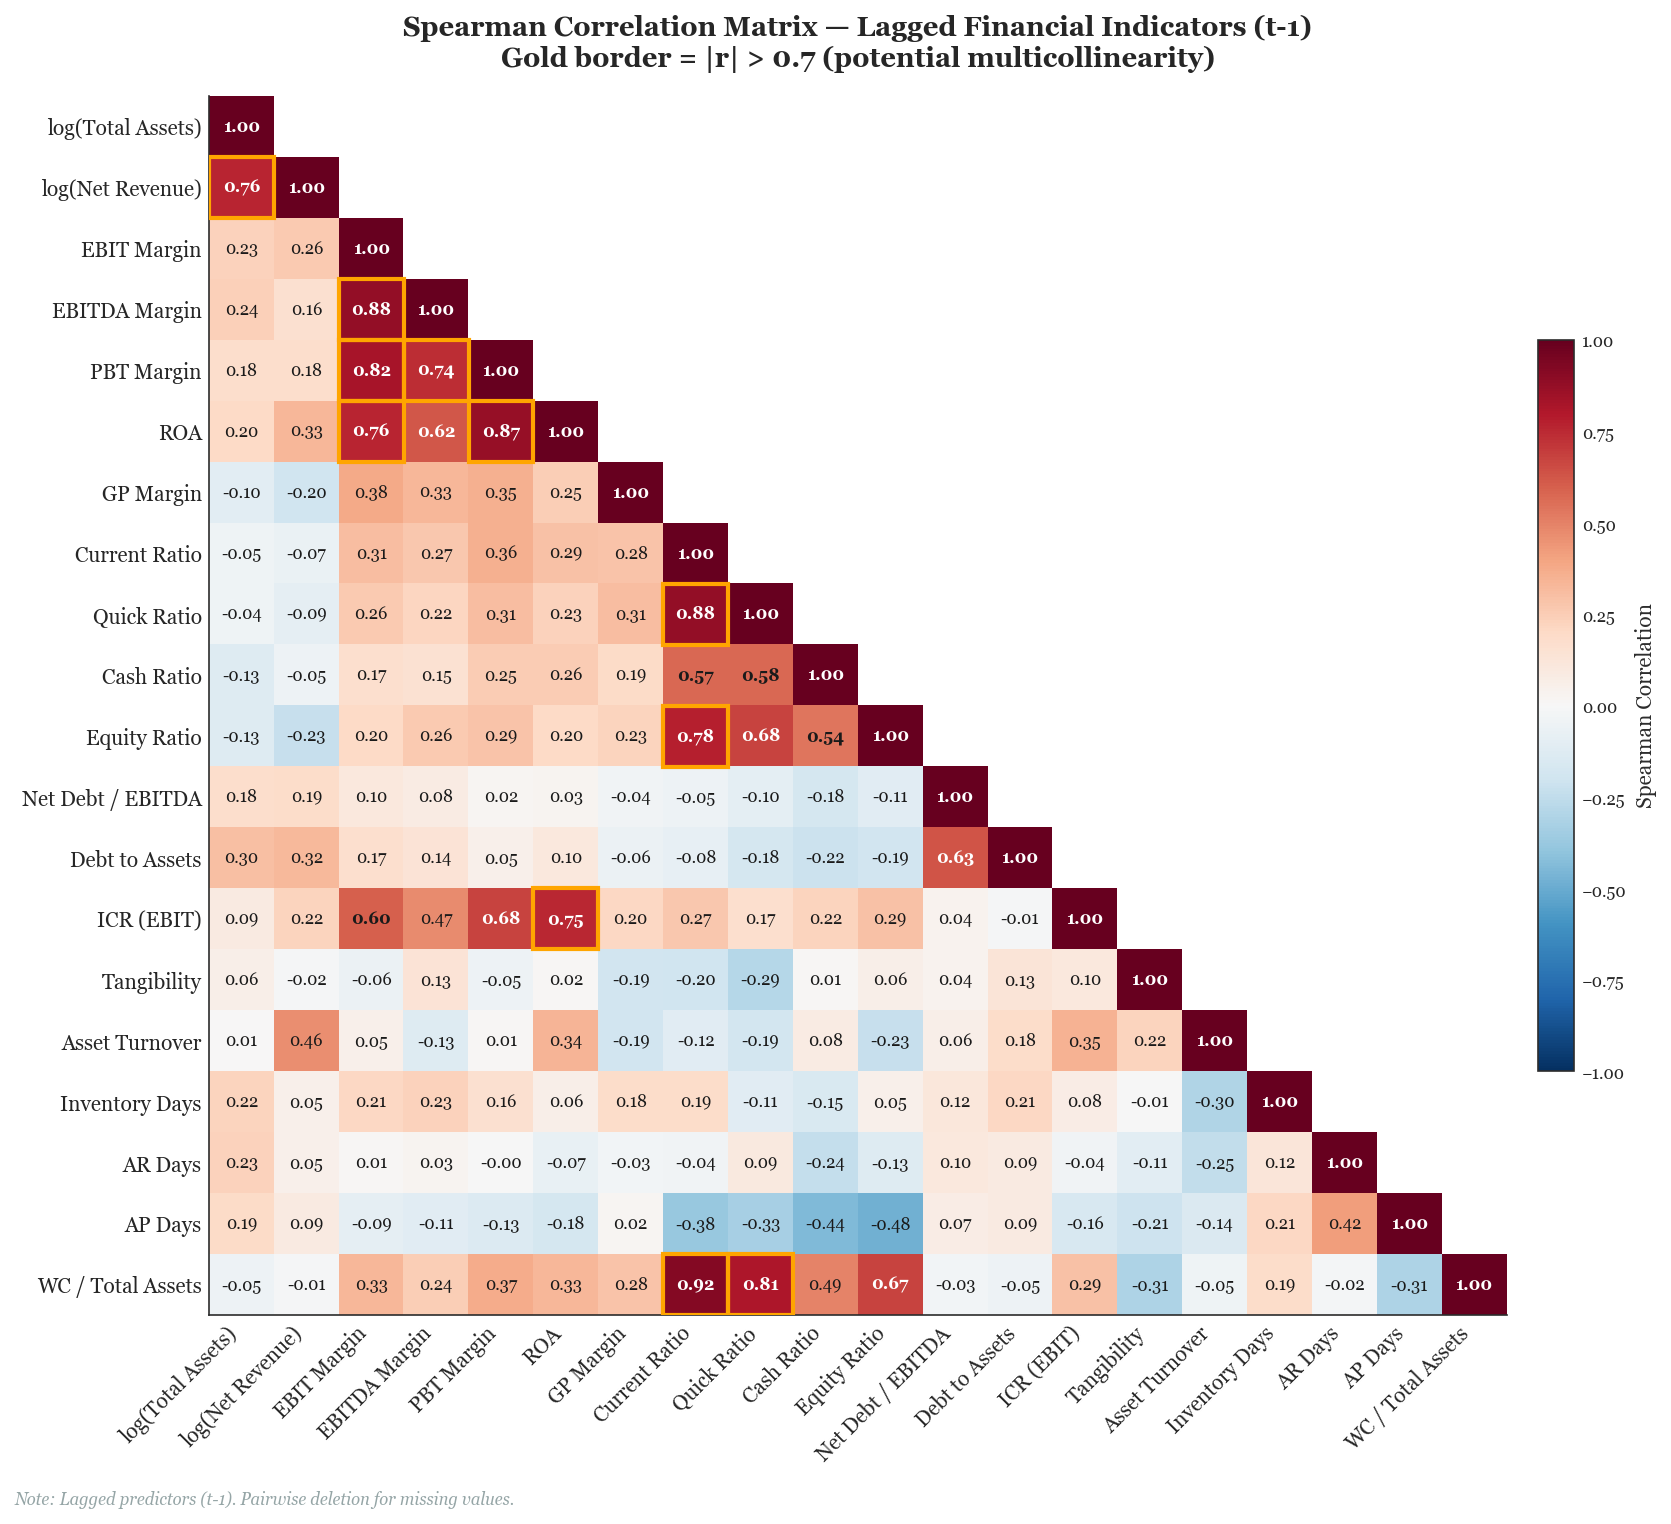

In [10]:
fig, ax = plt.subplots(figsize=(12, 10))

mask        = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
corr_masked = corr_matrix.copy()
corr_masked[mask] = np.nan

im = ax.imshow(corr_masked.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        if mask[i, j]: continue
        val   = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.6 else '#1a1a1a'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8,
                color=color, fontweight='bold' if abs(val) > 0.5 else 'normal')

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        if mask[i, j] or i == j: continue
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                       fill=False, edgecolor='orange',
                                       linewidth=2.0, zorder=5))

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns.tolist(), rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index.tolist(), fontsize=10)
ax.tick_params(which='both', length=0)

cbar = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Spearman Correlation', fontsize=10)
cbar.ax.tick_params(labelsize=8)

ax.set_title('Spearman Correlation Matrix — Lagged Financial Indicators (t-1)\n'
             'Gold border = |r| > 0.7 (potential multicollinearity)',
             fontsize=13, fontweight='bold')
fig.text(0.01, -0.01, 'Note: Lagged predictors (t-1). Pairwise deletion for missing values.',
         fontsize=8, color=COLORS['neutral'], style='italic')

plt.tight_layout()
plt.grid(False)
plt.savefig('corr_matrix_lag_spearman.png', dpi=150)
plt.show()

## 4. Point-Biserial Correlation and Univariate Logit

Computing point-biserial correlation and fitting a separate univariate logit for each lagged indicator. Reporting McFadden R² as a measure of univariate predictive power.

In [11]:
print('POINT-BISERIAL CORRELATION + UNIVARIATE LOGIT (Lagged t-1)')
print('=' * 90)

for var, var_label in ALL_DEP_VARS:
    print(f'\n{var_label}')
    print('-' * 90)
    rows = []
    for col in LAG_COLS:
        temp = df[[col, var]].dropna()
        X    = temp[col].values
        y    = temp[var].values

        pb_r, pb_p = stats.pointbiserialr(y, X)

        X_const = sm.add_constant(X)
        try:
            logit_m = sm.Logit(y, X_const).fit(disp=0)
            coef     = logit_m.params[1]
            p_val    = logit_m.pvalues[1]
            mcfadden = 1 - logit_m.llf / logit_m.llnull
            stars    = '***' if p_val < 0.01 else ('**' if p_val < 0.05 else ('*' if p_val < 0.1 else ''))
        except Exception:
            coef, p_val, mcfadden, stars = np.nan, np.nan, np.nan, ''

        rows.append({
            'Indicator'    : LAG_LABELS.get(col, col),
            'PB corr (r)'  : round(pb_r, 3),
            'PB p-value'   : round(pb_p, 4),
            'Logit coef'   : round(coef, 3) if not np.isnan(coef) else np.nan,
            'Logit p-value': round(p_val, 4) if not np.isnan(p_val) else np.nan,
            'McFadden R2'  : round(mcfadden, 4) if not np.isnan(mcfadden) else np.nan,
            'Sig'          : stars,
            'N'            : len(temp),
        })
    print(pd.DataFrame(rows).to_string(index=False))

POINT-BISERIAL CORRELATION + UNIVARIATE LOGIT (Lagged t-1)

Y1: Has Credit
------------------------------------------------------------------------------------------
        Indicator  PB corr (r)  PB p-value  Logit coef  Logit p-value  McFadden R2 Sig     N
log(Total Assets)        0.282         0.0       0.373            0.0       0.0810 *** 62943
 log(Net Revenue)        0.309         0.0       0.361            0.0       0.0948 *** 54290
      EBIT Margin        0.140         0.0       1.241            0.0       0.0198 *** 54290
    EBITDA Margin        0.120         0.0       1.068            0.0       0.0132 *** 54290
       PBT Margin        0.071         0.0       0.667            0.0       0.0047 *** 54290
              ROA        0.079         0.0       1.435            0.0       0.0058 *** 62943
        GP Margin       -0.116         0.0      -0.912            0.0       0.0124 *** 54290
    Current Ratio       -0.156         0.0      -0.029            0.0       0.0343 *** 619

## 5. Main Logit Models Model-1–Model-5 — setup, VIF and estimation

Defining five progressive specifications from a baseline to a full model with sector FE and frontline controls. Running VIF on main predictors only (excluding FE dummies per Hair et al. 2019).

In [12]:
# Sector dummies — Other as reference
df['Sector Group'] = pd.Categorical(
    df['Sector Group'],
    categories=['Other', 'Agriculture', 'Manufacturing',
                'Wholesale & Retail Trade', 'Energy', 'Mining'],
    ordered=False
)
sector_dummies = pd.get_dummies(df['Sector Group'], prefix='Sector', drop_first=True).astype(float)

# Year FE — ref = 2018
year_dummies_full = pd.get_dummies(df['Year'], prefix='Year', drop_first=True).astype(float)

print('Sector dummies (ref=Other):', sector_dummies.columns.tolist())
print('Year dummies:', year_dummies_full.columns.tolist())

Sector dummies (ref=Other): ['Sector_Agriculture', 'Sector_Manufacturing', 'Sector_Wholesale & Retail Trade', 'Sector_Energy', 'Sector_Mining']
Year dummies: ['Year_2019.0', 'Year_2020.0', 'Year_2021.0', 'Year_2022.0', 'Year_2023.0', 'Year_2024.0']


In [13]:
# Model specifications
m1_cols = ['EBIT_Margin_w_lag1', 'Equity_Ratio_w_lag1', 'NetDebt_to_EBITDA_w_lag1', 'Firm Age']
m2_cols = m1_cols + ['Quick_Ratio_w_lag1', 'Cash_Ratio_w_lag1']
m3_cols = m2_cols + ['Tangibility_w_lag1', 'Asset_Turnover_w_lag1',
                     'Inventory_Days_w_lag1', 'AR_Days_w_lag1', 'AP_Days_w_lag1']

specs = {
    'M1 (Baseline)'                    : {'cols': m1_cols, 'sector_fe': False, 'frontline': False},
    'M2 (M1 + Liquidity)'              : {'cols': m2_cols, 'sector_fe': False, 'frontline': False},
    'M3 (M2 + Collateral + Activity)'  : {'cols': m3_cols, 'sector_fe': False, 'frontline': False},
    'M4 (M3 + Sector FE)'              : {'cols': m3_cols, 'sector_fe': True,  'frontline': False},
    'M5 (M4 + Frontline — FINAL)'      : {'cols': m3_cols, 'sector_fe': True,  'frontline': True},
}


def run_logit(spec_cols, sector_fe, frontline, proxy=MAIN_DEP_VAR):
    """Fit logit with full Year FE and firm-clustered standard errors."""
    all_cols = spec_cols.copy()
    if frontline:
        all_cols += ['Frontline_2014', 'Frontline_2022']

    temp = df[all_cols + [proxy, 'Firm ID']].copy()
    if sector_fe:
        temp = pd.concat([temp, sector_dummies], axis=1)
        temp = temp.loc[:, ~temp.columns.duplicated()]

    temp = pd.concat([temp, year_dummies_full], axis=1)
    temp = temp.loc[:, ~temp.columns.duplicated()].dropna()

    firm_ids = temp['Firm ID'].values
    temp     = temp.drop(columns=['Firm ID'])
    X        = sm.add_constant(temp[[c for c in temp.columns if c != proxy]].astype(float))
    y        = temp[proxy].astype(float)

    model = sm.Logit(y, X).fit(
        method='newton', maxiter=1000, disp=False,
        cov_type='cluster', cov_kwds={'groups': firm_ids}
    )
    return model, len(temp)


def calc_vif(cols):
    """Compute VIF for a set of columns."""
    temp             = df[cols].dropna().astype(float)
    vif              = pd.DataFrame()
    vif['Variable']  = temp.columns
    vif['VIF']       = [variance_inflation_factor(temp.values, i) for i in range(temp.shape[1])]
    vif['Variable']  = vif['Variable'].str.replace('_w_lag1', '').str.replace('_lag1', '')
    vif['Status']    = vif['VIF'].apply(
        lambda x: 'HIGH >10' if x > 10 else ('WARN 5-10' if x > 5 else ('WARN 2-5' if x > 2 else 'ok <2'))
    )
    return vif, len(temp)


def fmt_coef(model, var):
    """Format coefficient with significance stars."""
    if var not in model.params:
        return f"{'—':>12}"
    coef = model.params[var]
    pval = model.pvalues[var]
    if np.isnan(pval):
        return f"{coef:>8.4f}{'':>3}"
    sig = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else ''))
    return f"{coef:>8.4f}{sig:>3}"


print('Setup complete.')
print(f'Models: {list(specs.keys())}')
print('Year FE: all years (2019-2024), ref=2018')
print('Standard errors: clustered by Firm ID')

Setup complete.
Models: ['M1 (Baseline)', 'M2 (M1 + Liquidity)', 'M3 (M2 + Collateral + Activity)', 'M4 (M3 + Sector FE)', 'M5 (M4 + Frontline — FINAL)']
Year FE: all years (2019-2024), ref=2018
Standard errors: clustered by Firm ID


In [14]:
print('VIF RESULTS — MAIN PREDICTORS ONLY')
print('(Year FE and Sector FE excluded per Hair et al. 2019)')
print('=' * 60)

for model_name in ['M1 (Baseline)', 'M2 (M1 + Liquidity)', 'M3 (M2 + Collateral + Activity)']:
    print(f'\n{model_name}')
    print('-' * 60)
    vif_data, n_obs = calc_vif(specs[model_name]['cols'])
    problems = vif_data[vif_data['VIF'] > 5]
    if len(problems) > 0:
        print('! PROBLEMS (VIF > 5):')
        print(problems.round(2).to_string(index=False))
    else:
        print('ok All VIF < 5')
    print(vif_data.round(3).to_string(index=False))
    print(f'N observations: {n_obs:,}')

print('\nM4, M5 — same predictors as M3 — VIF identical.')

VIF RESULTS — MAIN PREDICTORS ONLY
(Year FE and Sector FE excluded per Hair et al. 2019)

M1 (Baseline)
------------------------------------------------------------
ok All VIF < 5
         Variable   VIF   Status
      EBIT_Margin 1.053    ok <2
     Equity_Ratio 2.020 WARN 2-5
NetDebt_to_EBITDA 1.167    ok <2
         Firm Age 2.210 WARN 2-5
N observations: 54,103

M2 (M1 + Liquidity)
------------------------------------------------------------
ok All VIF < 5
         Variable   VIF   Status
      EBIT_Margin 1.066    ok <2
     Equity_Ratio 2.455 WARN 2-5
NetDebt_to_EBITDA 1.173    ok <2
         Firm Age 2.226 WARN 2-5
      Quick_Ratio 1.769    ok <2
       Cash_Ratio 1.887    ok <2
N observations: 53,645

M3 (M2 + Collateral + Activity)
------------------------------------------------------------
! PROBLEMS (VIF > 5):
Variable  VIF    Status
Firm Age 5.01 WARN 5-10
         Variable   VIF    Status
      EBIT_Margin 1.181     ok <2
     Equity_Ratio 2.956  WARN 2-5
NetDebt_to_EBIT

In [15]:
# Run M1–M5
results = {}
print('RUNNING LOGIT MODELS M1-M5')
print('=' * 65)

for model_name, spec in specs.items():
    model, n_obs = run_logit(spec['cols'], spec['sector_fe'], spec['frontline'])
    results[model_name] = {'model': model, 'n_obs': n_obs}
    mcf = 1 - model.llf / model.llnull
    auc = roc_auc_score(model.model.endog, model.predict())
    print(f"{model_name}:")
    print(f"  N={n_obs:,}  McFadden R2={mcf:.4f}  AIC={model.aic:.1f}  AUC={auc:.4f}")

RUNNING LOGIT MODELS M1-M5
M1 (Baseline):
  N=51,731  McFadden R2=0.0967  AIC=38506.9  AUC=0.7488
M2 (M1 + Liquidity):
  N=51,283  McFadden R2=0.1136  AIC=37653.8  AUC=0.7635
M3 (M2 + Collateral + Activity):
  N=46,380  McFadden R2=0.1132  AIC=35812.5  AUC=0.7612


/opt/homebrew/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


M4 (M3 + Sector FE):
  N=46,380  McFadden R2=0.1432  AIC=34611.8  AUC=0.7763
M5 (M4 + Frontline — FINAL):
  N=46,380  McFadden R2=0.1443  AIC=34572.8  AUC=0.7768


In [16]:
# Coefficients table M1–M5
print('FULL COEFFICIENTS TABLE — M1 through M5')
print('=' * 120)

all_main_vars = []
for spec in specs.values():
    for col in spec['cols']:
        clean = col.replace('_w_lag1', '').replace('_lag1', '')
        if clean not in all_main_vars:
            all_main_vars.append(clean)
for v in ['Frontline_2014', 'Frontline_2022']:
    if v not in all_main_vars:
        all_main_vars.append(v)

model_short = ['M1', 'M2', 'M3', 'M4', 'M5']
print(f"{'Variable':<32}" + ''.join(f"{s:>12}" for s in model_short))
print('-' * 120)

print('--- Financial Indicators ---')
for var in all_main_vars:
    row = f"{var:<32}"
    for model_name in specs.keys():
        m = results[model_name]['model']
        pname = next((p for p in [var + '_w_lag1', var + '_lag1', var] if p in m.params), None)
        row += fmt_coef(m, pname) if pname else f"{'—':>12}"
    print(row)

print('\n--- Sector Fixed Effects (ref = Other) ---')
for var in sector_dummies.columns:
    row = f"{var.replace('Sector_', ''):<32}"
    for model_name in specs.keys():
        row += fmt_coef(results[model_name]['model'], var)
    print(row)

print('\n--- Year FE (ref = 2018) ---')
year_vars = sorted([c for c in results['M5 (M4 + Frontline — FINAL)']['model'].params.index
                    if c.startswith('Year_')])
for var in year_vars:
    row = f"{var.replace('Year_', 'Year_').replace('.0', ''):<32}"
    for model_name in specs.keys():
        row += fmt_coef(results[model_name]['model'], var)
    print(row)

print('\n' + '-' * 120)
for stat_name, func in [
    ('McFadden R2',  lambda m: f"{1 - m.llf/m.llnull:>12.4f}"),
    ('AUC',          lambda m: f"{roc_auc_score(m.model.endog, m.predict()):>12.4f}"),
    ('AIC',          lambda m: f"{m.aic:>12.1f}"),
    ('BIC',          lambda m: f"{m.bic:>12.1f}"),
    ('N obs',        lambda m: f"{int(m.nobs):>12,}"),
    ('LLR p-value',  lambda m: f"{m.llr_pvalue:>12.4f}"),
]:
    row = f"{stat_name:<32}"
    for model_name in specs.keys():
        row += func(results[model_name]['model'])
    print(row)

print('\nNote: *** p<0.01, ** p<0.05, * p<0.1')
print('Full Year FE included in all models (ref=2018).')
print('Sector FE ref = Other. Standard errors clustered by Firm ID.')

FULL COEFFICIENTS TABLE — M1 through M5
Variable                                  M1          M2          M3          M4          M5
------------------------------------------------------------------------------------------------------------------------
--- Financial Indicators ---
EBIT_Margin                       1.3839***  1.4557***  1.5009***  1.2310***  1.2182***
Equity_Ratio                     -0.1262***  0.2615***  0.1984***  0.0640     0.0617   
NetDebt_to_EBITDA                 0.8437***  0.8003***  0.7566***  0.6851***  0.6842***
Firm Age                          0.0043 ** -0.0002    -0.0036  * -0.0096*** -0.0095***
Quick_Ratio                                — -0.0189*** -0.0072*** -0.0041    -0.0041   
Cash_Ratio                                 — -0.2516*** -0.2903*** -0.2463*** -0.2450***
Tangibility                                —           — -0.2337*** -0.0086    -0.0064   
Asset_Turnover                             —           —  0.0781***  0.0495***  0.0501***
Invento

## 6. Alternative specifications — profitability, liquidity and activity groups

Systematically comparing alternative indicator choices within each group, keeping all other predictors constant. Winner at each step carries forward as the new base.

In [17]:
print('VIF — STEP 1: PROFITABILITY')
print('=' * 60)

for name, cols in [
    ('M5_EBIT (base)', m3_cols),
    ('A1_EBITDA', ['EBITDA_Margin_w_lag1', 'Equity_Ratio_w_lag1',
                   'NetDebt_to_EBITDA_w_lag1', 'Firm Age',
                   'Quick_Ratio_w_lag1', 'Cash_Ratio_w_lag1',
                   'Tangibility_w_lag1', 'Asset_Turnover_w_lag1',
                   'Inventory_Days_w_lag1', 'AR_Days_w_lag1', 'AP_Days_w_lag1']),
    ('A2_ROA',    ['ROA_w_lag1', 'Equity_Ratio_w_lag1',
                   'NetDebt_to_EBITDA_w_lag1', 'Firm Age',
                   'Quick_Ratio_w_lag1', 'Cash_Ratio_w_lag1',
                   'Tangibility_w_lag1', 'Asset_Turnover_w_lag1',
                   'Inventory_Days_w_lag1', 'AR_Days_w_lag1', 'AP_Days_w_lag1']),
]:
    vif_data, n_obs = calc_vif(cols)
    print(f'\n{name}  (N={n_obs:,})')
    print('-' * 50)
    print(vif_data.round(2).to_string(index=False))

VIF — STEP 1: PROFITABILITY

M5_EBIT (base)  (N=48,678)
--------------------------------------------------
         Variable  VIF    Status
      EBIT_Margin 1.18     ok <2
     Equity_Ratio 2.96  WARN 2-5
NetDebt_to_EBITDA 1.23     ok <2
         Firm Age 5.01 WARN 5-10
      Quick_Ratio 1.87     ok <2
       Cash_Ratio 2.01  WARN 2-5
      Tangibility 2.38  WARN 2-5
   Asset_Turnover 1.79     ok <2
   Inventory_Days 1.97     ok <2
          AR_Days 1.89     ok <2
          AP_Days 2.10  WARN 2-5

A1_EBITDA  (N=48,678)
--------------------------------------------------
         Variable  VIF    Status
    EBITDA_Margin 1.24     ok <2
     Equity_Ratio 2.97  WARN 2-5
NetDebt_to_EBITDA 1.23     ok <2
         Firm Age 5.01 WARN 5-10
      Quick_Ratio 1.87     ok <2
       Cash_Ratio 2.02  WARN 2-5
      Tangibility 2.31  WARN 2-5
   Asset_Turnover 1.79     ok <2
   Inventory_Days 1.99     ok <2
          AR_Days 1.87     ok <2
          AP_Days 2.09  WARN 2-5

A2_ROA  (N=48,678)
-------

In [18]:
# Helper: run and compare a set of alternative specs
def compare_specs(alt_dict, base_name, step_title):
    print(f'\n{step_title}')
    print('=' * 65)
    col_names = list(alt_dict.keys())
    print(f"{'Metric':<20}" + ''.join(f"{n:>14}" for n in col_names))
    print('-' * (20 + 14 * len(col_names)))

    res = {}
    met = {}
    for name, cols in alt_dict.items():
        model, n_obs = run_logit(cols, sector_fe=True, frontline=True)
        res[name] = {'model': model, 'n_obs': n_obs}
        met[name] = {
            'McF': 1 - model.llf / model.llnull,
            'AIC': model.aic, 'BIC': model.bic,
            'AUC': roc_auc_score(model.model.endog, model.predict()),
            'N':   n_obs,
        }

    for stat in ['McF', 'AIC', 'BIC', 'AUC', 'N']:
        row = f"{stat:<20}"
        for name in col_names:
            val = met[name][stat]
            row += f"{val:>14.4f}" if stat != 'N' else f"{val:>14,}"
        print(row)

    print(f'\nDecision rule: better if AIC lower AND McFadden R2 higher than {base_name}')
    base_aic, base_mcf = met[base_name]['AIC'], met[base_name]['McF']
    best = base_name
    for name in col_names:
        if name == base_name: continue
        aic_better = met[name]['AIC'] < base_aic
        mcf_better = met[name]['McF'] > base_mcf
        if aic_better and mcf_better:
            print(f'  -> {name}: BETTER (AIC down, R2 up)')
            if met[name]['AIC'] < met[best]['AIC']: best = name
        elif aic_better:
            print(f'  -> {name}: lower AIC only — keep {base_name}')
        elif mcf_better:
            print(f'  -> {name}: higher R2 only — keep {base_name}')
        else:
            print(f'  -> {name}: no improvement — keep {base_name}')
    print(f'  Winner: {best}')
    return res, best


# Step 1: Profitability group
alt_profitability = {
    'M5_EBIT (base)': m3_cols,
    'A1_EBITDA': ['EBITDA_Margin_w_lag1', 'Equity_Ratio_w_lag1', 'NetDebt_to_EBITDA_w_lag1',
                  'Firm Age', 'Quick_Ratio_w_lag1', 'Cash_Ratio_w_lag1', 'Tangibility_w_lag1',
                  'Asset_Turnover_w_lag1', 'Inventory_Days_w_lag1', 'AR_Days_w_lag1', 'AP_Days_w_lag1'],
    'A2_ROA':   ['ROA_w_lag1', 'Equity_Ratio_w_lag1', 'NetDebt_to_EBITDA_w_lag1',
                  'Firm Age', 'Quick_Ratio_w_lag1', 'Cash_Ratio_w_lag1', 'Tangibility_w_lag1',
                  'Asset_Turnover_w_lag1', 'Inventory_Days_w_lag1', 'AR_Days_w_lag1', 'AP_Days_w_lag1'],
}
res_prof, winner_prof = compare_specs(alt_profitability, 'M5_EBIT (base)', 'STEP 1: PROFITABILITY')


STEP 1: PROFITABILITY
Metric              M5_EBIT (base)     A1_EBITDA        A2_ROA
--------------------------------------------------------------
McF                         0.1443        0.1442        0.1463
AIC                     34572.7754    34576.0423    34492.9444
BIC                     34782.6464    34785.9133    34702.8154
AUC                         0.7768        0.7762        0.7754
N                           46,380        46,380        46,380

Decision rule: better if AIC lower AND McFadden R2 higher than M5_EBIT (base)
  -> A1_EBITDA: no improvement — keep M5_EBIT (base)
  -> A2_ROA: BETTER (AIC down, R2 up)
  Winner: A2_ROA


In [19]:
print('VIF — STEP 2: LIQUIDITY (base = A2_ROA)')
print('=' * 60)
base_cols_a2 = [
    'ROA_w_lag1', 'Equity_Ratio_w_lag1', 'NetDebt_to_EBITDA_w_lag1', 'Firm Age',
    'Quick_Ratio_w_lag1', 'Cash_Ratio_w_lag1', 'Tangibility_w_lag1',
    'Asset_Turnover_w_lag1', 'Inventory_Days_w_lag1', 'AR_Days_w_lag1', 'AP_Days_w_lag1',
]

for name, cols in [
    ('A2_ROA (base)', base_cols_a2),
    ('A3_Current', ['ROA_w_lag1', 'Equity_Ratio_w_lag1',
                    'NetDebt_to_EBITDA_w_lag1', 'Firm Age',
                    'Current_Ratio_w_lag1', 'Cash_Ratio_w_lag1',
                    'Tangibility_w_lag1', 'Asset_Turnover_w_lag1',
                    'Inventory_Days_w_lag1', 'AR_Days_w_lag1', 'AP_Days_w_lag1']),
]:
    vif_data, n_obs = calc_vif(cols)
    print(f'\n{name}  (N={n_obs:,})')
    print('-' * 50)
    print(vif_data.round(2).to_string(index=False))

VIF — STEP 2: LIQUIDITY (base = A2_ROA)

A2_ROA (base)  (N=48,678)
--------------------------------------------------
         Variable  VIF    Status
              ROA 1.42     ok <2
     Equity_Ratio 3.28  WARN 2-5
NetDebt_to_EBITDA 1.21     ok <2
         Firm Age 5.03 WARN 5-10
      Quick_Ratio 1.88     ok <2
       Cash_Ratio 2.02  WARN 2-5
      Tangibility 2.38  WARN 2-5
   Asset_Turnover 1.88     ok <2
   Inventory_Days 1.97     ok <2
          AR_Days 1.87     ok <2
          AP_Days 2.07  WARN 2-5

A3_Current  (N=48,678)
--------------------------------------------------
         Variable  VIF    Status
              ROA 1.41     ok <2
     Equity_Ratio 3.28  WARN 2-5
NetDebt_to_EBITDA 1.20     ok <2
         Firm Age 5.03 WARN 5-10
    Current_Ratio 2.06  WARN 2-5
       Cash_Ratio 2.09  WARN 2-5
      Tangibility 2.37  WARN 2-5
   Asset_Turnover 1.88     ok <2
   Inventory_Days 1.99     ok <2
          AR_Days 1.85     ok <2
          AP_Days 2.08  WARN 2-5


In [20]:
# Base columns for A2_ROA (winner from profitability step)
base_cols_a2 = [
    'ROA_w_lag1', 'Equity_Ratio_w_lag1', 'NetDebt_to_EBITDA_w_lag1', 'Firm Age',
    'Quick_Ratio_w_lag1', 'Cash_Ratio_w_lag1', 'Tangibility_w_lag1',
    'Asset_Turnover_w_lag1', 'Inventory_Days_w_lag1', 'AR_Days_w_lag1', 'AP_Days_w_lag1',
]

# Step 2: Liquidity group
alt_liquidity = {
    'A2_ROA (base)': base_cols_a2,
    'A3_Current': ['ROA_w_lag1', 'Equity_Ratio_w_lag1', 'NetDebt_to_EBITDA_w_lag1', 'Firm Age',
                   'Current_Ratio_w_lag1', 'Cash_Ratio_w_lag1', 'Tangibility_w_lag1',
                   'Asset_Turnover_w_lag1', 'Inventory_Days_w_lag1', 'AR_Days_w_lag1', 'AP_Days_w_lag1'],
}
res_liq, winner_liq = compare_specs(alt_liquidity, 'A2_ROA (base)', 'STEP 2: LIQUIDITY')


STEP 2: LIQUIDITY
Metric               A2_ROA (base)    A3_Current
------------------------------------------------
McF                         0.1463        0.1463
AIC                     34492.9444    34493.1142
BIC                     34702.8154    34702.9852
AUC                         0.7754        0.7754
N                           46,380        46,380

Decision rule: better if AIC lower AND McFadden R2 higher than A2_ROA (base)
  -> A3_Current: no improvement — keep A2_ROA (base)
  Winner: A2_ROA (base)


In [21]:
print('VIF — STEP 3: ACTIVITY (base = A2_ROA)')
print('=' * 60)

for name, cols in [
    ('A2_ROA (base)', base_cols_a2),
    ('A4_logRev', ['ROA_w_lag1', 'Equity_Ratio_w_lag1',
                   'NetDebt_to_EBITDA_w_lag1', 'Firm Age',
                   'Quick_Ratio_w_lag1', 'Cash_Ratio_w_lag1',
                   'Tangibility_w_lag1', 'log_Net_Revenue_w_lag1',
                   'Inventory_Days_w_lag1', 'AR_Days_w_lag1', 'AP_Days_w_lag1']),
    ('A5_logAssets', ['ROA_w_lag1', 'Equity_Ratio_w_lag1',
                      'NetDebt_to_EBITDA_w_lag1', 'Firm Age',
                      'Quick_Ratio_w_lag1', 'Cash_Ratio_w_lag1',
                      'Tangibility_w_lag1', 'log_Total_Assets_w_lag1',
                      'Inventory_Days_w_lag1', 'AR_Days_w_lag1', 'AP_Days_w_lag1']),
]:
    vif_data, n_obs = calc_vif(cols)
    print(f'\n{name}  (N={n_obs:,})')
    print('-' * 50)
    print(vif_data.round(2).to_string(index=False))

VIF — STEP 3: ACTIVITY (base = A2_ROA)

A2_ROA (base)  (N=48,678)
--------------------------------------------------
         Variable  VIF    Status
              ROA 1.42     ok <2
     Equity_Ratio 3.28  WARN 2-5
NetDebt_to_EBITDA 1.21     ok <2
         Firm Age 5.03 WARN 5-10
      Quick_Ratio 1.88     ok <2
       Cash_Ratio 2.02  WARN 2-5
      Tangibility 2.38  WARN 2-5
   Asset_Turnover 1.88     ok <2
   Inventory_Days 1.97     ok <2
          AR_Days 1.87     ok <2
          AP_Days 2.07  WARN 2-5

A4_logRev  (N=48,678)
--------------------------------------------------
         Variable  VIF    Status
              ROA 1.44     ok <2
     Equity_Ratio 3.31  WARN 2-5
NetDebt_to_EBITDA 1.30     ok <2
         Firm Age 6.33 WARN 5-10
      Quick_Ratio 1.88     ok <2
       Cash_Ratio 2.02  WARN 2-5
      Tangibility 2.42  WARN 2-5
  log_Net_Revenue 6.22 WARN 5-10
   Inventory_Days 1.86     ok <2
          AR_Days 1.86     ok <2
          AP_Days 2.12  WARN 2-5

A5_logAssets  (N

In [22]:
# Step 3: Activity group
a4_cols = ['ROA_w_lag1', 'Equity_Ratio_w_lag1', 'NetDebt_to_EBITDA_w_lag1', 'Firm Age',
           'Quick_Ratio_w_lag1', 'Cash_Ratio_w_lag1', 'Tangibility_w_lag1',
           'log_Net_Revenue_w_lag1', 'Inventory_Days_w_lag1', 'AR_Days_w_lag1', 'AP_Days_w_lag1']
a5_cols = ['ROA_w_lag1', 'Equity_Ratio_w_lag1', 'NetDebt_to_EBITDA_w_lag1', 'Firm Age',
           'Quick_Ratio_w_lag1', 'Cash_Ratio_w_lag1', 'Tangibility_w_lag1',
           'log_Total_Assets_w_lag1', 'Inventory_Days_w_lag1', 'AR_Days_w_lag1', 'AP_Days_w_lag1']

alt_activity = {'A2_ROA (base)': base_cols_a2, 'A4_logRev': a4_cols, 'A5_logAssets': a5_cols}
res_act, winner_act = compare_specs(alt_activity, 'A2_ROA (base)', 'STEP 3: ACTIVITY')


STEP 3: ACTIVITY
Metric               A2_ROA (base)     A4_logRev  A5_logAssets
--------------------------------------------------------------
McF                         0.1463        0.1667        0.1613
AIC                     34492.9444    33668.1060    33886.7978
BIC                     34702.8154    33877.9770    34096.6687
AUC                         0.7754        0.7917        0.7867
N                           46,380        46,380        46,380

Decision rule: better if AIC lower AND McFadden R2 higher than A2_ROA (base)
  -> A4_logRev: BETTER (AIC down, R2 up)
  -> A5_logAssets: BETTER (AIC down, R2 up)
  Winner: A4_logRev


## Full coefficients table – Model-1 through Alternative-5 models specifications

In [23]:
alt_models = {}

for name, cols in [
    ('A1_EBITDA',    alt_profitability['A1_EBITDA']),
    ('A2_ROA',       base_cols_a2),
    ('A3_Current',   alt_liquidity['A3_Current']),
    ('A4_logRev',    a4_cols),
    ('A5_logAssets', a5_cols),
]:
    m, n = run_logit(cols, sector_fe=True, frontline=True)
    alt_models[name] = {'model': m, 'n_obs': n}

all_models = {k.split('(')[0].strip(): v for k, v in results.items()}
all_models.update(alt_models)

model_names = ['M1', 'M2', 'M3', 'M4', 'M5', 'A1_EBITDA', 'A2_ROA', 'A3_Current', 'A4_logRev', 'A5_logAssets']

all_fin_vars = [
    'EBIT_Margin', 'EBITDA_Margin', 'ROA',
    'Equity_Ratio', 'NetDebt_to_EBITDA', 'Firm Age',
    'Quick_Ratio', 'Current_Ratio', 'Cash_Ratio', 'Tangibility',
    'Asset_Turnover', 'log_Net_Revenue', 'log_Total_Assets',
    'Inventory_Days', 'AR_Days', 'AP_Days',
    'Frontline_2014', 'Frontline_2022',
]

print('FULL COEFFICIENTS TABLE — M1 through A5')
print('=' * 140)
print(f"{'Variable':<22}" + ''.join(f"{n:>12}" for n in model_names))
print('-' * 140)

print('--- Financial Indicators ---')
for var in all_fin_vars:
    row = f"{var:<22}"
    for mname in model_names:
        m = all_models[mname]['model']
        pname = next((p for p in [var + '_w_lag1', var + '_lag1', var] if p in m.params), None)
        row += fmt_coef(m, pname) if pname else f"{'—':>12}"
    print(row)

print('\n--- Sector FE (ref = Other) ---')
for var in sector_dummies.columns:
    row = f"{var.replace('Sector_', ''):<22}"
    for mname in model_names:
        row += fmt_coef(all_models[mname]['model'], var)
    print(row)

print('\n' + '-' * 140)
for stat_name, func in [
    ('McFadden R2', lambda m: f"{1 - m.llf/m.llnull:>12.4f}"),
    ('AIC',         lambda m: f"{m.aic:>12.1f}"),
    ('BIC',         lambda m: f"{m.bic:>12.1f}"),
    ('AUC',         lambda m: f"{roc_auc_score(m.model.endog, m.predict()):>12.4f}"),
    ('N obs',       lambda m: f"{int(m.nobs):>12,}"),
]:
    row = f"{stat_name:<22}"
    for mname in model_names:
        row += func(all_models[mname]['model'])
    print(row)

print('\nNote: *** p<0.01, ** p<0.05, * p<0.1')
print('M5 = main specification. A1-A5 = alternative specifications. Winner: A2_ROA.')

FULL COEFFICIENTS TABLE — M1 through A5
Variable                        M1          M2          M3          M4          M5   A1_EBITDA      A2_ROA  A3_Current   A4_logRevA5_logAssets
--------------------------------------------------------------------------------------------------------------------------------------------
--- Financial Indicators ---
EBIT_Margin             1.3839***  1.4557***  1.5009***  1.2310***  1.2182***           —           —           —           —           —
EBITDA_Margin                    —           —           —           —           —  1.2568***           —           —           —           —
ROA                              —           —           —           —           —           —  2.5003***  2.5131***  1.6470***  2.1320***
Equity_Ratio           -0.1262***  0.2615***  0.1984***  0.0640     0.0617     0.0782    -0.0899  * -0.1036 **  0.0137    -0.0568   
NetDebt_to_EBITDA       0.8437***  0.8003***  0.7566***  0.6851***  0.6842***  0.6897***  0.733

## 8.  Alternative-2_ROA significant predictors only

Retaining only predictors with p < 0.1 from A2_ROA and re-estimating. Comparing AIC and McFadden R² against the full A2_ROA.

In [24]:
m_a2 = alt_models['A2_ROA']['model']

print('SIGNIFICANT PREDICTORS IN A2_ROA (p < 0.1):')
print('=' * 55)

sig_cols_a2 = []
for col in base_cols_a2:
    clean  = col.replace('_w_lag1', '').replace('_lag1', '')
    pname  = next((p for p in m_a2.params.index
                   if clean in p and not any(x in p for x in ['Year', 'Sector', 'Frontline', 'const'])),
                  None)
    if pname:
        pval = m_a2.pvalues[pname]
        sig  = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else ''))
        if pval < 0.1:
            sig_cols_a2.append(col)
            print(f'  [+] {clean:<25} p={pval:.4f} {sig}')
        else:
            print(f'  [-] {clean:<25} p={pval:.4f} — excluded')

print(f'\nFinal predictors: {[c.replace("_w_lag1", "").replace("_lag1", "") for c in sig_cols_a2]}')

SIGNIFICANT PREDICTORS IN A2_ROA (p < 0.1):
  [+] ROA                       p=0.0000 ***
  [+] Equity_Ratio              p=0.0753 *
  [+] NetDebt_to_EBITDA         p=0.0000 ***
  [+] Firm Age                  p=0.0001 ***
  [-] Quick_Ratio               p=0.2584 — excluded
  [+] Cash_Ratio                p=0.0000 ***
  [-] Tangibility               p=0.7482 — excluded
  [-] Asset_Turnover            p=0.3484 — excluded
  [-] Inventory_Days            p=0.1180 — excluded
  [+] AR_Days                   p=0.0037 ***
  [+] AP_Days                   p=0.0000 ***

Final predictors: ['ROA', 'Equity_Ratio', 'NetDebt_to_EBITDA', 'Firm Age', 'Cash_Ratio', 'AR_Days', 'AP_Days']


In [25]:
print('\nVIF CHECK — Final Model')
vif_data, _ = calc_vif(sig_cols_a2)
problems = vif_data[vif_data['VIF'] > 5]
if len(problems) > 0:
    print('! PROBLEMS:')
    print(problems.round(2).to_string(index=False))
else:
    print('ok All VIF < 5')
print(vif_data.round(2).to_string(index=False))

m_final, n_final = run_logit(sig_cols_a2, sector_fe=True, frontline=True)
mcf_final = 1 - m_final.llf / m_final.llnull
auc_final = roc_auc_score(m_final.model.endog, m_final.predict())

m_a2_mcf = 1 - m_a2.llf / m_a2.llnull
m_a2_auc = roc_auc_score(m_a2.model.endog, m_a2.predict())

print('\nCOMPARISON: A2_ROA (all) vs Final (significant only)')
print('=' * 55)
print(f"{'Metric':<20} {'A2_ROA':>16} {'Final':>16} {'Better':>10}")
print('-' * 55)
for name, v1, v2, direction in [
    ('McFadden R2', m_a2_mcf,       mcf_final,       'higher'),
    ('AIC',         m_a2.aic,        m_final.aic,     'lower'),
    ('BIC',         m_a2.bic,        m_final.bic,     'lower'),
    ('AUC',         m_a2_auc,        auc_final,       'higher'),
]:
    better = 'Final' if (v2 < v1 if direction == 'lower' else v2 > v1) else 'A2_ROA'
    print(f"{name:<20} {v1:>16.4f} {v2:>16.4f} {better:>10}")
print(f"{'N obs':<20} {int(m_a2.nobs):>16,} {n_final:>16,}")

print('\nDecision: Final preferred if AIC lower AND R2 higher.')
if m_final.aic < m_a2.aic and mcf_final > m_a2_mcf:
    print('-> FINAL MODEL accepted')
else:
    print('-> Keep A2_ROA — removing insignificant vars did not improve fit')

print('\nCOEFFICIENTS — FINAL MODEL')
print('=' * 60)
print(f"{'Variable':<28} {'Coef':>10} {'Std Err':>10} {'p-value':>10} {'Sig':>5}")
print('-' * 60)
for var in m_final.params.index:
    if var == 'const' or var.startswith('Year_'): continue
    coef  = m_final.params[var]
    se    = m_final.bse[var]
    pval  = m_final.pvalues[var]
    sig   = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else ''))
    clean = var.replace('_w_lag1', '').replace('_lag1', '').replace('Sector_', '')
    print(f"{clean:<28} {coef:>10.4f} {se:>10.4f} {pval:>10.4f} {sig:>5}")
print(f'\nMcFadden R2 = {mcf_final:.4f}  AIC = {m_final.aic:.1f}  AUC = {auc_final:.4f}  N = {n_final:,}')


VIF CHECK — Final Model
ok All VIF < 5
         Variable  VIF   Status
              ROA 1.29    ok <2
     Equity_Ratio 2.79 WARN 2-5
NetDebt_to_EBITDA 1.17    ok <2
         Firm Age 2.94 WARN 2-5
       Cash_Ratio 1.30    ok <2
          AR_Days 1.79    ok <2
          AP_Days 1.83    ok <2

COMPARISON: A2_ROA (all) vs Final (significant only)
Metric                         A2_ROA            Final     Better
-------------------------------------------------------
McFadden R2                    0.1463           0.1462     A2_ROA
AIC                        34492.9444       34489.5104      Final
BIC                        34702.8154       34664.4029      Final
AUC                            0.7754           0.7752     A2_ROA
N obs                          46,380           46,380

Decision: Final preferred if AIC lower AND R2 higher.
-> Keep A2_ROA — removing insignificant vars did not improve fit

COEFFICIENTS — FINAL MODEL
Variable                           Coef    Std Err    p-value

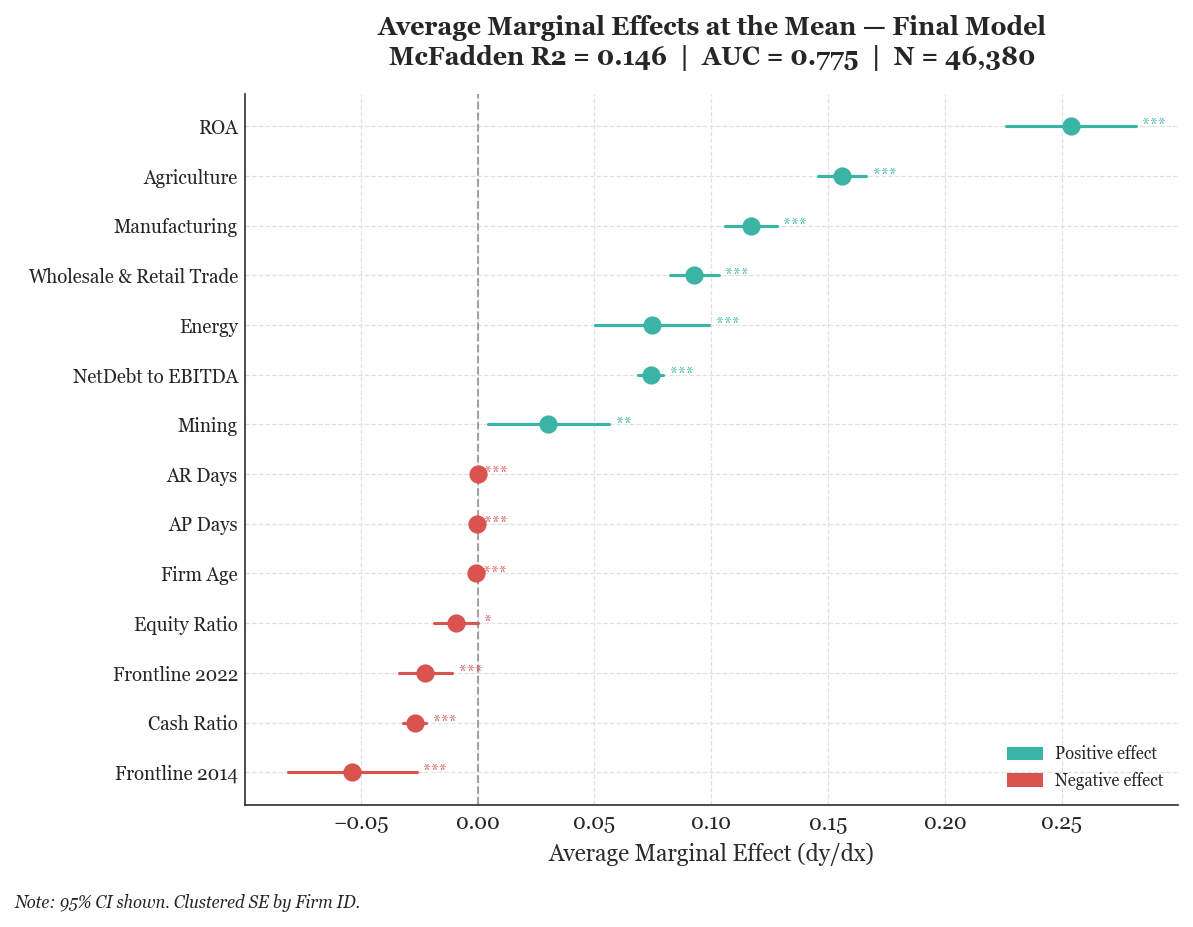


MARGINAL EFFECTS — FINAL MODEL
Variable                          dy/dx    Std Err    p-value   Sig
------------------------------------------------------------
ROA                              0.2539     0.0142     0.0000   ***
Agriculture                      0.1560     0.0053     0.0000   ***
Manufacturing                    0.1170     0.0056     0.0000   ***
Wholesale & Retail Trade         0.0928     0.0053     0.0000   ***
Energy                           0.0747     0.0124     0.0000   ***
NetDebt to EBITDA                0.0740     0.0028     0.0000   ***
Mining                           0.0303     0.0133     0.0227    **
AR Days                         -0.0001     0.0000     0.0005   ***
AP Days                         -0.0001     0.0000     0.0000   ***
Firm Age                        -0.0008     0.0002     0.0003   ***
Equity Ratio                    -0.0093     0.0048     0.0514     *
Frontline 2022                  -0.0224     0.0059     0.0001   ***
Cash Ratio             

In [26]:
# Average marginal effects for the final model
me_res     = m_final.get_margeff(method='dydx', at='mean')
me_summary = me_res.summary_frame()

me_df = pd.DataFrame({
    'Variable' : me_summary.index,
    'dy/dx'    : me_summary['dy/dx'],
    'Std Error': me_summary['Std. Err.'],
    'p-value'  : me_summary['Pr(>|z|)'],
}).reset_index(drop=True)

me_df['Variable'] = me_df['Variable'].str.replace('_w_lag1', '').str.replace('_lag1', '').str.replace('Sector_', '').str.replace('_', ' ')
me_plot = me_df[
    ~me_df['Variable'].str.startswith('Year') &
    ~me_df['Variable'].str.startswith('const')
].copy().sort_values('dy/dx', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))

for i, (_, row) in enumerate(me_plot.iterrows()):
    color   = COLORS['positive'] if row['dy/dx'] > 0 else COLORS['negative']
    alpha   = 1.0 if row['p-value'] < 0.1 else 0.3
    ci_low  = row['dy/dx'] - 1.96 * row['Std Error']
    ci_high = row['dy/dx'] + 1.96 * row['Std Error']
    ax.plot([ci_low, ci_high], [i, i], color=color, alpha=alpha, linewidth=1.5)
    ax.scatter(row['dy/dx'], i, color=color, alpha=alpha, s=60, zorder=3,
               marker='o' if row['p-value'] < 0.1 else 's')
    stars = '***' if row['p-value'] < 0.01 else ('**' if row['p-value'] < 0.05 else ('*' if row['p-value'] < 0.1 else ''))
    ax.text(ci_high + 0.001, i, f' {stars}', va='center', fontsize=8, color=color, alpha=alpha)

ax.axvline(x=0, color='grey', linewidth=1.0, linestyle='--', alpha=0.7)
ax.set_yticks(range(len(me_plot)))
ax.set_yticklabels(me_plot['Variable'], fontsize=9)
ax.set_xlabel('Average Marginal Effect (dy/dx)', fontsize=11)
ax.set_title(
    f'Average Marginal Effects at the Mean — Final Model\n'
    f'McFadden R2 = {mcf_final:.3f}  |  AUC = {auc_final:.3f}  |  N = {n_final:,}',
    fontsize=12, fontweight='bold'
)
ax.legend(handles=[
    mpatches.Patch(color=COLORS['positive'], label='Positive effect'),
    mpatches.Patch(color=COLORS['negative'], label='Negative effect'),
], fontsize=8, loc='lower right')
fig.text(0.01, -0.02, 'Note: 95% CI shown. Clustered SE by Firm ID.',
         fontsize=8, style='italic')
plt.tight_layout()
plt.savefig('marginal_effects_final.png', dpi=150)
plt.show()

print('\nMARGINAL EFFECTS — FINAL MODEL')
print('=' * 60)
print(f"{'Variable':<28} {'dy/dx':>10} {'Std Err':>10} {'p-value':>10} {'Sig':>5}")
print('-' * 60)
for _, row in me_plot.sort_values('dy/dx', ascending=False).iterrows():
    sig = '***' if row['p-value'] < 0.01 else ('**' if row['p-value'] < 0.05 else ('*' if row['p-value'] < 0.1 else ''))
    print(f"{row['Variable']:<28} {row['dy/dx']:>10.4f} {row['Std Error']:>10.4f} {row['p-value']:>10.4f} {sig:>5}")

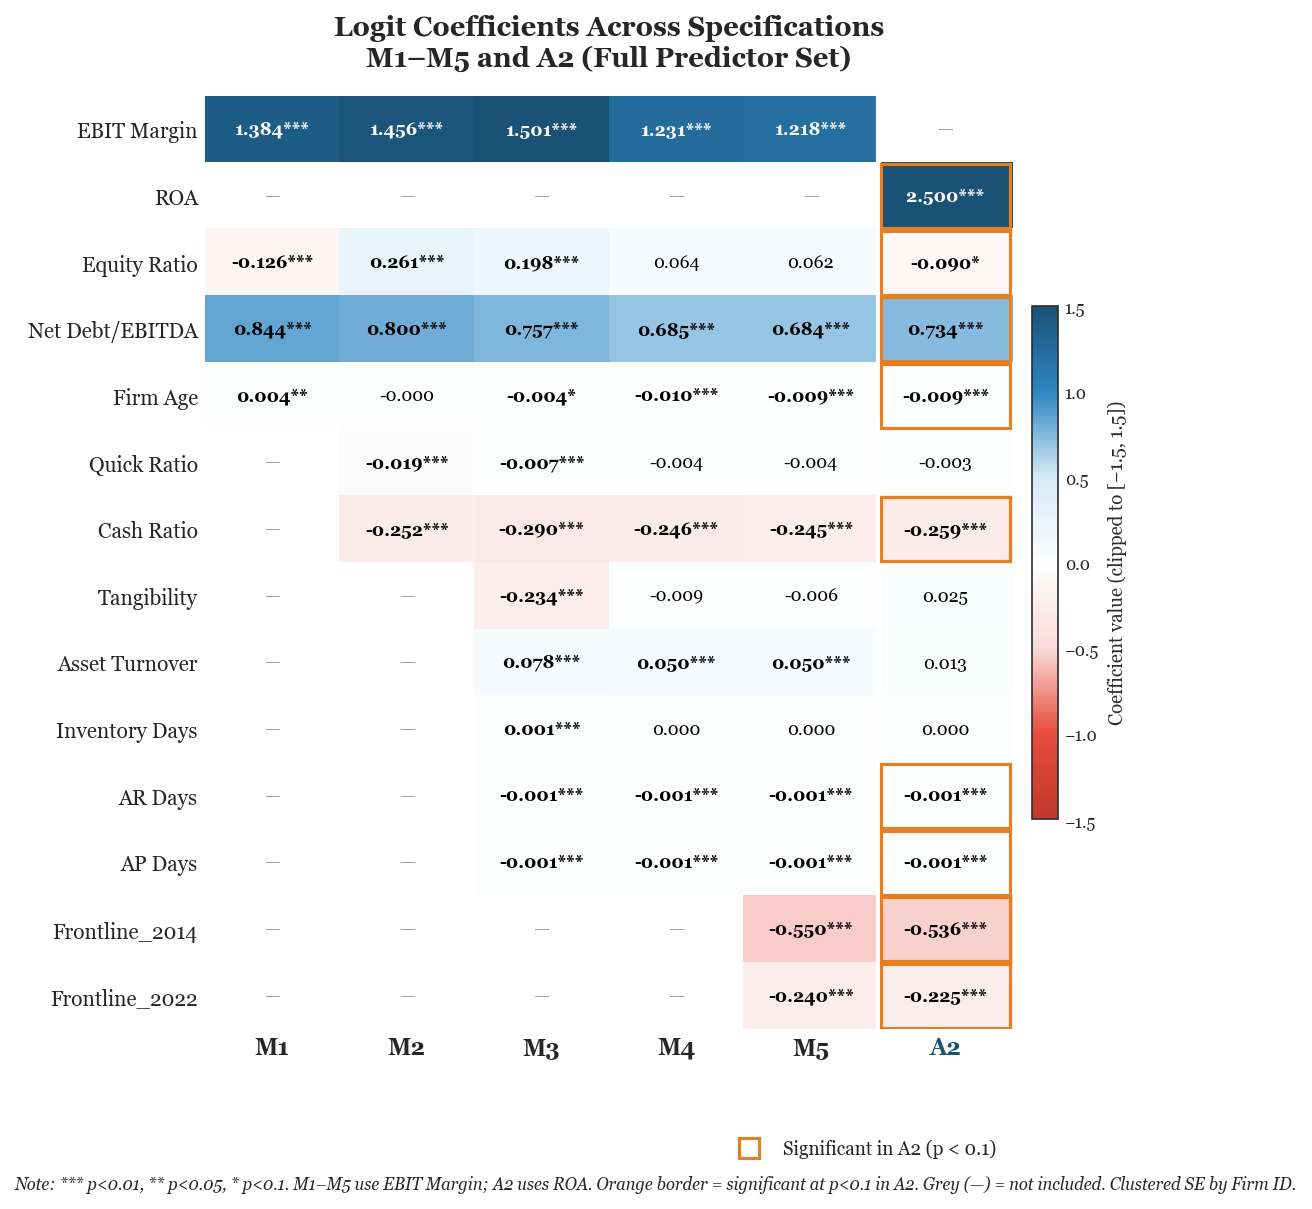

Saved: coefficients_heatmap.png


In [27]:

# COEFFICIENTS HEATMAP — M1-M5 + A2_ROA

import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Custom diverging colormap
cmap_custom = mcolors.LinearSegmentedColormap.from_list(
    'coef_map',
    ['#c0392b', '#e74c3c', '#fadbd8', '#fdfefe', '#d6eaf8', '#2e86c1', '#1a5276'],
    N=256
)

heatmap_vars_full = {
    'EBIT Margin'    : 'EBIT_Margin_w_lag1',
    'ROA'            : 'ROA_w_lag1',
    'Equity Ratio'   : 'Equity_Ratio_w_lag1',
    'Net Debt/EBITDA': 'NetDebt_to_EBITDA_w_lag1',
    'Firm Age'       : 'Firm Age',
    'Quick Ratio'    : 'Quick_Ratio_w_lag1',
    'Cash Ratio'     : 'Cash_Ratio_w_lag1',
    'Tangibility'    : 'Tangibility_w_lag1',
    'Asset Turnover' : 'Asset_Turnover_w_lag1',
    'Inventory Days' : 'Inventory_Days_w_lag1',
    'AR Days'        : 'AR_Days_w_lag1',
    'AP Days'        : 'AP_Days_w_lag1',
    'Frontline_2014' : 'Frontline_2014',
    'Frontline_2022' : 'Frontline_2022',
}

model_names_hm = ['M1', 'M2', 'M3', 'M4', 'M5', 'A2']
model_objects  = [
    results['M1 (Baseline)']['model'],
    results['M2 (M1 + Liquidity)']['model'],
    results['M3 (M2 + Collateral + Activity)']['model'],
    results['M4 (M3 + Sector FE)']['model'],
    results['M5 (M4 + Frontline — FINAL)']['model'],
    alt_models['A2_ROA']['model'],
]

n_vars, n_models = len(heatmap_vars_full), len(model_names_hm)
coef_matrix = np.full((n_vars, n_models), np.nan)
pval_matrix = np.full((n_vars, n_models), np.nan)

for j, model in enumerate(model_objects):
    for i, (display, var) in enumerate(heatmap_vars_full.items()):
        if var in model.params:
            coef_matrix[i, j] = model.params[var]
            pval_matrix[i, j] = model.pvalues[var]

coef_clipped = np.clip(coef_matrix, -1.5, 1.5)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(coef_clipped, cmap=cmap_custom, aspect='auto', vmin=-1.5, vmax=1.5)

for i in range(n_vars):
    for j in range(n_models):
        if np.isnan(coef_matrix[i, j]):
            ax.text(j, i, '—', ha='center', va='center', fontsize=9, color='grey')
        else:
            coef = coef_matrix[i, j]
            pval = pval_matrix[i, j]
            stars = '' if np.isnan(pval) else ('***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else '')))
            txt_color = 'white' if abs(coef) > 1.2 else 'black'
            ax.text(j, i, f'{coef:.3f}{stars}', ha='center', va='center',
                    fontsize=8.5, color=txt_color,
                    fontweight='bold' if stars else 'normal')

            if stars != '' and j == 5:
                ax.add_patch(plt.Rectangle(
                    (j - 0.48, i - 0.48), 0.96, 0.96,
                    linewidth=1.5, edgecolor='#E67E22', facecolor='none', zorder=5
                ))

ax.axvline(x=4.5, color='white', linewidth=2.5, zorder=4)

ax.set_xticks(range(n_models))
ax.set_xticklabels(model_names_hm, fontsize=11, fontweight='bold')
ax.set_yticks(range(n_vars))
ax.set_yticklabels(list(heatmap_vars_full.keys()), fontsize=10)
ax.get_xticklabels()[-1].set_color('#1A5276')
ax.tick_params(which='both', length=0)
ax.grid(False)
for spine in ax.spines.values(): spine.set_visible(False)

ax.set_title('Logit Coefficients Across Specifications\nM1–M5 and A2 (Full Predictor Set)',
             fontsize=13, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, shrink=0.55, pad=0.02)
cbar.set_label('Coefficient value (clipped to [−1.5, 1.5])', fontsize=9)
cbar.ax.tick_params(labelsize=8)

ax.legend(handles=[
    Line2D([0], [0], marker='s', color='w', markerfacecolor='none',
           markeredgecolor='#E67E22', markeredgewidth=1.5, markersize=10,
           label='Significant in A2 (p < 0.1)'),
], fontsize=9, loc='upper right', bbox_to_anchor=(1.0, -0.1), frameon=False)

fig.text(0.01, 0,
         'Note: *** p<0.01, ** p<0.05, * p<0.1. '
         'M1–M5 use EBIT Margin; A2 uses ROA. '
         'Orange border = significant at p<0.1 in A2. '
         'Grey (—) = not included. Clustered SE by Firm ID.',
         fontsize=8, style='italic')

plt.tight_layout()
plt.savefig('coefficients_heatmap.png', dpi=150)
plt.show()
print('Saved: coefficients_heatmap.png')

## 9. Robustness checks R1–R5

Validating A2_ROA results across alternative dependent variables (R1, R2), leverage proxy (R3), active-firm subsample (R4), and crisis-dummies-only time control (R5).

In [28]:
rob_base_cols = base_cols_a2.copy()

# Crisis-only dummies for R5
crisis_dummies_r5 = pd.get_dummies(df['Year'], prefix='Year', drop_first=False)
rename_map = {}
for col_name in crisis_dummies_r5.columns:
    if '2020' in str(col_name): rename_map[col_name] = 'COVID_Dummy'
    if '2022' in str(col_name): rename_map[col_name] = 'War_Dummy'
crisis_dummies_r5 = crisis_dummies_r5.rename(columns=rename_map)[['COVID_Dummy', 'War_Dummy']].astype(float)


def run_logit_robust(spec_cols, sector_fe, frontline, time_control, data, proxy=MAIN_DEP_VAR):
    """Logit with flexible time control (full Year FE or crisis dummies only)."""
    all_cols = spec_cols.copy()
    if frontline:
        all_cols += ['Frontline_2014', 'Frontline_2022']

    # Crisis dummy columns exist only in crisis_dummies_r5, not in data
    # so do NOT add them to all_cols here
    temp = data[all_cols + [proxy, 'Firm ID']].copy()

    if sector_fe:
        sect = pd.get_dummies(data['Sector Group'], prefix='Sector', drop_first=True).astype(float)
        temp = pd.concat([temp, sect], axis=1).loc[:, lambda d: ~d.columns.duplicated()]

    if time_control == 'year_fe':
        year = pd.get_dummies(data['Year'], prefix='Year', drop_first=True).astype(float)
        temp = pd.concat([temp, year], axis=1).loc[:, lambda d: ~d.columns.duplicated()]
    elif time_control == 'crisis_only':
        # Join crisis dummies by index alignment
        cris = crisis_dummies_r5.loc[data.index]
        temp = pd.concat([temp, cris], axis=1).loc[:, lambda d: ~d.columns.duplicated()]

    temp     = temp.dropna()
    firm_ids = temp['Firm ID'].values
    temp     = temp.drop(columns=['Firm ID'])
    X = sm.add_constant(temp[[c for c in temp.columns if c != proxy]].astype(float))
    y = temp[proxy].astype(float)

    model = sm.Logit(y, X).fit(
        method='newton', maxiter=1000, disp=False,
        cov_type='cluster', cov_kwds={'groups': firm_ids}
    )
    return model, len(temp)


robustness_specs = {
    'R1 (Y1: Has Credit)': {
        'cols': rob_base_cols, 'sector_fe': True, 'frontline': True,
        'time_control': 'year_fe', 'data': df, 'proxy': 'Y1_Has_Credit',
    },
    'R2 (Y2: Active Credit User)': {
        'cols': rob_base_cols, 'sector_fe': True, 'frontline': True,
        'time_control': 'year_fe', 'data': df, 'proxy': 'Y2_Active_Credit_User',
    },
    'R3 (Debt/Assets instead of NetDebt/EBITDA)': {
        'cols': [c for c in rob_base_cols if c != 'NetDebt_to_EBITDA_w_lag1'] + ['Debt_to_Assets_w_lag1'],
        'sector_fe': True, 'frontline': True, 'time_control': 'year_fe', 'data': df,
    },
    'R4 (Active firms only)': {
        'cols': rob_base_cols, 'sector_fe': True, 'frontline': True,
        'time_control': 'year_fe',
        'data': df[df['Firm Status'] == 'Не перебуває в процесі припинення'].copy(),
    },
    'R5 (Crisis dummies only)': {
        'cols': rob_base_cols, 'sector_fe': True, 'frontline': True,
        'time_control': 'crisis_only', 'data': df,
    },
}

results_rob = {}
print('RUNNING ROBUSTNESS CHECKS R1-R5')
print('Base model: A2_ROA (all predictors)')
print('=' * 65)

for rob_name, spec in robustness_specs.items():
    proxy = spec.get('proxy', MAIN_DEP_VAR)
    try:
        model, n_obs = run_logit_robust(
            spec['cols'], spec['sector_fe'], spec['frontline'],
            spec['time_control'], spec['data'], proxy=proxy
        )
        results_rob[rob_name] = {'model': model, 'n_obs': n_obs}
        mcf = 1 - model.llf / model.llnull
        auc = roc_auc_score(model.model.endog, model.predict())
        print(f"{rob_name}:")
        print(f"  N={n_obs:,}  McF={mcf:.4f}  AUC={auc:.4f}")
    except Exception as e:
        print(f"  (!) {rob_name}: {str(e)[:60]}")

RUNNING ROBUSTNESS CHECKS R1-R5
Base model: A2_ROA (all predictors)
R1 (Y1: Has Credit):
  N=48,678  McF=0.3636  AUC=0.8724
R2 (Y2: Active Credit User):
  N=46,380  McF=0.2198  AUC=0.8169
R3 (Debt/Assets instead of NetDebt/EBITDA):
  N=46,514  McF=0.1642  AUC=0.7919
R4 (Active firms only):
  N=42,971  McF=0.1477  AUC=0.7758
R5 (Crisis dummies only):
  N=46,380  McF=0.1440  AUC=0.7738


In [29]:
# Robustness comparison table
key_vars = {
    'ROA':             'ROA_w_lag1',
    'NetDebt/EBITDA':  'NetDebt_to_EBITDA_w_lag1',
    'Debt_to_Assets':  'Debt_to_Assets_w_lag1',
    'Equity_Ratio':    'Equity_Ratio_w_lag1',
    'Cash_Ratio':      'Cash_Ratio_w_lag1',
    'Asset_Turnover':  'Asset_Turnover_w_lag1',
    'AR_Days':         'AR_Days_w_lag1',
    'AP_Days':         'AP_Days_w_lag1',
    'Firm Age':        'Firm Age',
    'COVID_Dummy':     'COVID_Dummy',
    'War_Dummy':       'War_Dummy',
    'Frontline_2014':  'Frontline_2014',
    'Frontline_2022':  'Frontline_2022',
}

rob_short = [f'R{i+1}' for i in range(len(robustness_specs))]

def fmt_rob(model, var):
    if var not in model.params: return f"{'—':>12}"
    coef = model.params[var]
    pval = model.pvalues[var]
    if np.isnan(pval): return f"{coef:>8.3f}{'':>4}"
    sig = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else ''))
    return f"{coef:>8.3f}{sig:>4}"

print('ROBUSTNESS COMPARISON TABLE')
print('=' * 90)
print(f"{'Variable':<22}" + f"{'A2_ROA':>12}" + ''.join(f"{s:>12}" for s in rob_short))
print('-' * 90)

for display_name, var_name in key_vars.items():
    row  = f"{display_name:<22}"
    row += fmt_rob(alt_models['A2_ROA']['model'], var_name)
    for rob_name in robustness_specs.keys():
        if rob_name not in results_rob:
            row += f"{'(!)':>12}"
        else:
            row += fmt_rob(results_rob[rob_name]['model'], var_name)
    print(row)

print('\n' + '-' * 90)
for stat_name, func in [
    ('McFadden R2', lambda m: f"{1 - m.llf/m.llnull:>12.4f}"),
    ('AIC',         lambda m: f"{m.aic:>12.1f}"),
    ('N obs',       lambda m: f"{int(m.nobs):>12,}"),
]:
    row  = f"{stat_name:<22}"
    row += func(alt_models['A2_ROA']['model'])
    for rob_name in robustness_specs.keys():
        row += func(results_rob[rob_name]['model']) if rob_name in results_rob else f"{'—':>12}"
    print(row)

print('\nNote: *** p<0.01, ** p<0.05, * p<0.1')
print('Base = A2_ROA with full Year FE, Sector FE, Frontline controls.')
print('R3: Debt to Assets — endogeneity concern, for comparison only.')
print('R5: COVID_Dummy (2020) + War_Dummy (2022) only, no full Year FE.')

ROBUSTNESS COMPARISON TABLE
Variable                    A2_ROA          R1          R2          R3          R4          R5
------------------------------------------------------------------------------------------
ROA                      2.500 ***   1.953 ***   2.230 ***   2.067 ***   2.360 ***   2.459 ***
NetDebt/EBITDA           0.734 ***   2.312 ***   1.159 ***           —   0.707 ***   0.730 ***
Debt_to_Assets                   —           —           —   8.242 ***           —           —
Equity_Ratio            -0.090   *  -0.390 ***  -0.338 ***   0.114  **  -0.151 ***  -0.097   *
Cash_Ratio              -0.259 ***  -0.253 ***  -0.239 ***  -0.243 ***  -0.251 ***  -0.256 ***
Asset_Turnover           0.013      -0.021      -0.013       0.008       0.025   *   0.014    
AR_Days                 -0.001 ***  -0.000      -0.000      -0.001 ***  -0.001 ***  -0.001 ***
AP_Days                 -0.001 ***  -0.001 ***  -0.001 ***  -0.001 ***  -0.001 ***  -0.001 ***
Firm Age                -0

## 10. Heterogeneity — crisis interactions and subperiod analysis

Testing whether financial determinants shift during COVID-19 (2020) and the full-scale war (2022) via interaction terms. Then re-estimating on pre-war and war-period subsamples.

In [30]:
hetero_base_cols = [
    'ROA_w_lag1', 'Equity_Ratio_w_lag1', 'NetDebt_to_EBITDA_w_lag1', 'Firm Age',
    'Quick_Ratio_w_lag1', 'Cash_Ratio_w_lag1', 'Tangibility_w_lag1',
    'Asset_Turnover_w_lag1', 'Inventory_Days_w_lag1', 'AR_Days_w_lag1', 'AP_Days_w_lag1',
]

interact_vars = [
    'ROA_w_lag1', 'Equity_Ratio_w_lag1', 'NetDebt_to_EBITDA_w_lag1',
    'Quick_Ratio_w_lag1', 'Cash_Ratio_w_lag1', 'Tangibility_w_lag1',
    'Asset_Turnover_w_lag1', 'Inventory_Days_w_lag1', 'AR_Days_w_lag1',
    'AP_Days_w_lag1', 'Firm Age',
]

df_interact = df.copy()
for var in interact_vars:
    clean = var.replace('_w_lag1', '').replace('_lag1', '')
    df_interact[f'COVID_{clean}'] = (df_interact['Year'] == 2020).astype(float) * df_interact[var]
    df_interact[f'War_{clean}']   = (df_interact['Year'] == 2022).astype(float) * df_interact[var]

covid_interact_cols = [f"COVID_{v.replace('_w_lag1','').replace('_lag1','')}" for v in interact_vars]
war_interact_cols   = [f"War_{v.replace('_w_lag1','').replace('_lag1','')}"   for v in interact_vars]

all_cols_int = (hetero_base_cols + ['Frontline_2014', 'Frontline_2022'] +
                covid_interact_cols + war_interact_cols)

temp = df_interact[all_cols_int + [MAIN_DEP_VAR, 'Firm ID']].copy()

sect_interact = pd.get_dummies(df_interact['Sector Group'], prefix='Sector', drop_first=True).astype(float)
temp = pd.concat([temp, sect_interact], axis=1)
temp = temp.loc[:, ~temp.columns.duplicated()]

year_interact = pd.get_dummies(df_interact['Year'], prefix='Year', drop_first=True).astype(float)
temp = pd.concat([temp, year_interact], axis=1)
temp = temp.loc[:, ~temp.columns.duplicated()]
temp = temp.dropna()

firm_ids_int = temp['Firm ID'].values
temp         = temp.drop(columns=['Firm ID'])

X_int = sm.add_constant(temp[[c for c in temp.columns if c != MAIN_DEP_VAR]].astype(float))
y_int = temp[MAIN_DEP_VAR].astype(float)

model_interact = sm.Logit(y_int, X_int).fit(
    method='newton', maxiter=1000, disp=False,
    cov_type='cluster', cov_kwds={'groups': firm_ids_int}
)

mcf = 1 - model_interact.llf / model_interact.llnull
auc = roc_auc_score(model_interact.model.endog, model_interact.predict())
print(f'CRISIS INTERACTION MODEL — N={len(temp):,}  McF={mcf:.4f}  AUC={auc:.4f}')

def print_interact_block(title, vars_list):
    print(f'\n--- {title} ---')
    print(f"{'Variable':<30} {'Coef':>10} {'p-value':>10} {'Sig':>5}")
    print('-' * 60)
    for var in vars_list:
        if var not in model_interact.params: continue
        coef = model_interact.params[var]
        pval = model_interact.pvalues[var]
        sig  = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else ''))
        print(f"{var:<30} {coef:>10.4f} {pval:>10.4f} {sig:>5}")

print_interact_block('Base effects (normal year)',            interact_vars)
print_interact_block('COVID interactions (Year_2020 x X)',   covid_interact_cols)
print_interact_block('War interactions (Year_2022 x X)',     war_interact_cols)

CRISIS INTERACTION MODEL — N=46,380  McF=0.1538  AUC=0.7804

--- Base effects (normal year) ---
Variable                             Coef    p-value   Sig
------------------------------------------------------------
ROA_w_lag1                         1.8402     0.0000   ***
Equity_Ratio_w_lag1                0.0185     0.7991      
NetDebt_to_EBITDA_w_lag1           0.6767     0.0000   ***
Quick_Ratio_w_lag1                -0.0063     0.1788      
Cash_Ratio_w_lag1                 -0.2627     0.0000   ***
Tangibility_w_lag1                -0.0854     0.7670      
Asset_Turnover_w_lag1              0.0666     0.0162    **
Inventory_Days_w_lag1              0.0000     0.9564      
AR_Days_w_lag1                    -0.0003     0.4074      
AP_Days_w_lag1                    -0.0010     0.0000   ***
Firm Age                          -0.0085     0.1302      

--- COVID interactions (Year_2020 x X) ---
Variable                             Coef    p-value   Sig
--------------------------------

In [31]:
# Subperiod analysis
subperiod_specs = {
    '2020-2021 (COVID period)': {
        'years': [2020, 2021], 'crisis': True, 'year_fe': False,
        'frontline': ['Frontline_2014'],
    },
    '2022-2024 (War period)': {
        'years': [2022, 2023, 2024], 'crisis': False, 'year_fe': True,
        'frontline': ['Frontline_2014', 'Frontline_2022'],
    },
}

results_subperiod = {}
print('\nSUBPERIOD ANALYSIS: 2020-2021 vs 2022-2024')
print('=' * 70)

for period_name, spec in subperiod_specs.items():
    print(f'\n{period_name}')
    df_period = df[df['Year'].isin(spec['years'])].copy()
    all_cols  = hetero_base_cols + spec['frontline']
    temp      = df_period[all_cols + [MAIN_DEP_VAR, 'Firm ID']].copy()
    temp      = pd.concat([temp,
                           pd.get_dummies(df_period['Sector Group'], prefix='Sector', drop_first=True).astype(float)],
                          axis=1).loc[:, lambda d: ~d.columns.duplicated()]

    if spec['crisis']:
        temp['COVID_Dummy'] = (df_period['Year'] == 2020).astype(float).values
    if spec['year_fe']:
        yr = pd.get_dummies(df_period['Year'], prefix='Year', drop_first=True).astype(float)
        temp = pd.concat([temp, yr], axis=1).loc[:, lambda d: ~d.columns.duplicated()]

    temp     = temp.dropna()
    firm_ids = temp['Firm ID'].values
    temp     = temp.drop(columns=['Firm ID'])
    X = sm.add_constant(temp[[c for c in temp.columns if c != MAIN_DEP_VAR]].astype(float))
    y = temp[MAIN_DEP_VAR].astype(float)

    model_per = None
    for method in ['newton', 'bfgs', 'lbfgs', 'nm']:
        try:
            model_per = sm.Logit(y, X).fit(
                method=method, maxiter=1000, disp=False,
                cov_type='cluster', cov_kwds={'groups': firm_ids}
            )
            print(f'  Converged with: {method}')
            break
        except Exception as e:
            print(f'  {method} failed: {str(e)[:40]}')

    if model_per is None:
        print('  (!) Could not converge')
        continue

    results_subperiod[period_name] = {'model': model_per, 'n_obs': len(temp)}
    mcf = 1 - model_per.llf / model_per.llnull
    auc = roc_auc_score(model_per.model.endog, model_per.predict())
    print(f'  N={len(temp):,}  McF={mcf:.4f}  AUC={auc:.4f}')

def fmt_sub(model, var):
    if var not in model.params: return f"{'—':>20}"
    coef = model.params[var]
    pval = model.pvalues[var]
    sig  = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else ''))
    return f"{coef:>16.4f}{sig:>4}"

print('\nSUBPERIOD COMPARISON TABLE')
print('=' * 75)
print(f"{'Variable':<32} {'2020-2021':>20} {'2022-2024':>20}")
print('-' * 75)
for var in hetero_base_cols:
    clean = var.replace('_w_lag1', '').replace('_lag1', '')
    row   = f"{clean:<32}"
    for period_name in subperiod_specs.keys():
        row += fmt_sub(results_subperiod[period_name]['model'], var) if period_name in results_subperiod else f"{'—':>20}"
    print(row)

for var in ['COVID_Dummy', 'Frontline_2014', 'Frontline_2022']:
    row = f"{var:<32}"
    for period_name in subperiod_specs.keys():
        row += fmt_sub(results_subperiod[period_name]['model'], var) if period_name in results_subperiod else f"{'—':>20}"
    print(row)

print('\n' + '-' * 75)
for stat_name, func in [
    ('McFadden R2', lambda m: f"{1 - m.llf/m.llnull:>20.4f}"),
    ('AUC',         lambda m: f"{roc_auc_score(m.model.endog, m.predict()):>20.4f}"),
    ('N obs',       lambda m: f"{int(m.nobs):>20,}"),
]:
    row = f"{stat_name:<32}"
    for period_name in subperiod_specs.keys():
        row += func(results_subperiod[period_name]['model']) if period_name in results_subperiod else f"{'—':>20}"
    print(row)

print('\nNote: *** p<0.01, ** p<0.05, * p<0.1')
print('2020-2021: COVID_Dummy (1=2020), Frontline_2014 only.')
print('2022-2024: Year FE for 2023-2024, Frontline_2014 + Frontline_2022.')
print('Clustered SE by Firm ID. Sector FE ref=Other.')


SUBPERIOD ANALYSIS: 2020-2021 vs 2022-2024

2020-2021 (COVID period)
  Converged with: newton
  N=13,298  McF=0.1637  AUC=0.7860

2022-2024 (War period)
  Converged with: newton
  N=23,936  McF=0.1609  AUC=0.7867

SUBPERIOD COMPARISON TABLE
Variable                                    2020-2021            2022-2024
---------------------------------------------------------------------------
ROA                                       2.1223 ***          3.0120 ***
Equity_Ratio                              0.1556   *         -0.3958 ***
NetDebt_to_EBITDA                         0.8570 ***          0.6929 ***
Firm Age                                 -0.0118 ***         -0.0039    
Quick_Ratio                              -0.0138   *          0.0031    
Cash_Ratio                               -0.6048 ***         -0.1925 ***
Tangibility                              -0.1932              0.1581    
Asset_Turnover                            0.0283             -0.0322   *
Inventory_Days         

## 11. Regional models

Re-estimating A2_ROA on three regional subsamples: non-frontline, Donetsk/Luhansk conflict zone (since 2014), and newly affected regions (from 2022).

In [32]:
df_non_front  = df[(df['Frontline_2014'] == 0) & (df['Frontline_2022'] == 0)].copy()
df_front_2014 = df[df['Frontline_2014'] == 1].copy()
df_front_2022 = df[(df['Frontline_2022'] == 1) & (df['Year'] >= 2022)].copy()

print('Regional subsamples:')
for name, data in [('Non-frontline', df_non_front), ('Frontline_2014', df_front_2014),
                   ('Frontline_2022 (2022-2024)', df_front_2022)]:
    print(f'  {name}: N={len(data):,}  Y3 mean={data[MAIN_DEP_VAR].mean():.3f}')


def run_regional_model(data, name):
    """Fit A2_ROA logit on a regional subsample (no frontline dummies)."""
    temp = data[hetero_base_cols + [MAIN_DEP_VAR, 'Firm ID']].copy()
    temp = pd.concat([temp,
                      pd.get_dummies(data['Sector Group'], prefix='Sector', drop_first=True).astype(float),
                      pd.get_dummies(data['Year'],         prefix='Year',   drop_first=True).astype(float)],
                     axis=1).loc[:, lambda d: ~d.columns.duplicated()].dropna()

    firm_ids = temp['Firm ID'].values
    temp     = temp.drop(columns=['Firm ID'])
    X = sm.add_constant(temp[[c for c in temp.columns if c != MAIN_DEP_VAR]].astype(float))
    y = temp[MAIN_DEP_VAR].astype(float)

    model = None
    for method in ['newton', 'bfgs', 'lbfgs', 'nm']:
        try:
            model = sm.Logit(y, X).fit(
                method=method, maxiter=1000, disp=False,
                cov_type='cluster', cov_kwds={'groups': firm_ids}
            )
            break
        except Exception:
            continue

    if model is None:
        print(f'  (!) {name}: could not converge')
        return None, 0

    mcf = 1 - model.llf / model.llnull
    auc = roc_auc_score(model.model.endog, model.predict())
    print(f'  {name}: N={len(temp):,}  McF={mcf:.4f}  AUC={auc:.4f}')
    return model, len(temp)


print('\nRUNNING REGIONAL MODELS')
model_non_front,  n_non  = run_regional_model(df_non_front,  'Non-frontline')
model_front_2014, n_2014 = run_regional_model(df_front_2014, 'Frontline_2014')
model_front_2022, n_2022 = run_regional_model(df_front_2022, 'Frontline_2022 (2022-2024)')

regional_models = {
    'Non-frontline':  model_non_front,
    'Frontline_2014': model_front_2014,
    'Frontline_2022': model_front_2022,
}

def fmt_reg(model, var):
    if model is None or var not in model.params: return f"{'—':>17}"
    coef = model.params[var]
    pval = model.pvalues[var]
    sig  = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else ''))
    return f"{coef:>13.4f}{sig:>4}"

print('\nREGIONAL MODELS COMPARISON TABLE')
print('=' * 85)
print(f"{'Variable':<32} {'Non-frontline':>17} {'Frontline_2014':>17} {'Frontline_2022':>17}")
print('-' * 85)
for var in hetero_base_cols:
    clean = var.replace('_w_lag1', '').replace('_lag1', '')
    row   = f"{clean:<32}" + ''.join(fmt_reg(m, var) for m in regional_models.values())
    print(row)

print('\n--- Sector FE (ref=Other) ---')
for var in sector_dummies.columns:
    row = f"{var.replace('Sector_', ''):<32}" + ''.join(fmt_reg(m, var) for m in regional_models.values())
    print(row)

print('\n' + '-' * 85)
for stat_name, func in [
    ('McFadden R2', lambda m: f"{1 - m.llf/m.llnull:>17.4f}" if m else f"{'—':>17}"),
    ('AUC',         lambda m: f"{roc_auc_score(m.model.endog, m.predict()):>17.4f}" if m else f"{'—':>17}"),
    ('N obs',       lambda m: f"{int(m.nobs):>17,}" if m else f"{'—':>17}"),
]:
    print(f"{stat_name:<32}" + ''.join(func(m) for m in regional_models.values()))

print('\nNote: *** p<0.01, ** p<0.05, * p<0.1')
print('Non-frontline: Frontline_2014=0 AND Frontline_2022=0 (all years).')
print('Frontline_2014: conflict zone since 2014 (all years).')
print('Frontline_2022: new frontline, 2022-2024 only.')
print('Year FE and Sector FE included. Clustered SE by Firm ID.')

Regional subsamples:
  Non-frontline: N=74,161  Y3 mean=0.126
  Frontline_2014: N=1,834  Y3 mean=0.066
  Frontline_2022 (2022-2024): N=5,067  Y3 mean=0.127

RUNNING REGIONAL MODELS
  Non-frontline: N=41,375  McF=0.1446  AUC=0.7741
  Frontline_2014: N=1,030  McF=0.2394  AUC=0.8527
  Frontline_2022 (2022-2024): N=3,975  McF=0.1600  AUC=0.7827

REGIONAL MODELS COMPARISON TABLE
Variable                             Non-frontline    Frontline_2014    Frontline_2022
-------------------------------------------------------------------------------------
ROA                                    2.3841 ***       1.5698           4.1050 ***
Equity_Ratio                          -0.0548           0.6265          -0.6183 ***
NetDebt_to_EBITDA                      0.7347 ***       0.8910 ***       0.7078 ***
Firm Age                              -0.0099 ***      -0.0432  **       0.0103    
Quick_Ratio                           -0.0020           0.0110          -0.0189   *
Cash_Ratio                    

/opt/homebrew/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 12. Sectoral models

Estimating separate logit models for each sector with sector-specific predictor sets (chosen based on EDA and VIF checks). Including crisis dummies and frontline controls.

In [33]:

# EFFECT SIZE BY SECTOR — ALL INDICATOR GROUPS

all_sector_indicators = {
    'Profitability'      : ['EBIT_Margin_w_lag1', 'EBITDA_Margin_w_lag1', 'ROA_w_lag1', 'GP_Margin_w_lag1'],
    'Leverage'           : ['NetDebt_to_EBITDA_w_lag1', 'Equity_Ratio_w_lag1'],
    'Liquidity'          : ['Quick_Ratio_w_lag1', 'Current_Ratio_w_lag1', 'Cash_Ratio_w_lag1'],
    'Collateral'         : ['Tangibility_w_lag1'],
    'Activity'           : ['Asset_Turnover_w_lag1', 'Inventory_Days_w_lag1', 'AR_Days_w_lag1',
                            'AP_Days_w_lag1', 'WC_to_Assets_w_lag1'],
    'Debt Service'       : ['ICR_EBIT_w_lag1'],
    'Firm Characteristics': ['Firm Age', 'log_Net_Revenue_w_lag1', 'log_Total_Assets_w_lag1'],
}

def get_effect_size(df_sect, col, proxy):
    """Rank-biserial correlation (Mann-Whitney U effect size) by sector."""
    temp = df_sect[[col, proxy]].dropna()
    g1   = temp[temp[proxy] == 1][col]
    g0   = temp[temp[proxy] == 0][col]
    if len(g1) < 10 or len(g0) < 10:
        return None, None
    u_stat, p_val = stats.mannwhitneyu(g1, g0, alternative='two-sided')
    r = 1 - (2 * u_stat) / (len(g1) * len(g0))
    return r, p_val


for group_name, indicators in all_sector_indicators.items():
    print(f"\n{'='*90}")
    print(f"GROUP: {group_name}")
    print(f"{'='*90}")

    header = f"{'Indicator':<28}" + ''.join(f"{s[:10]:>13}" for s in SECTOR_ORDER)
    print(header)
    print('-' * 90)

    for col in indicators:
        clean = col.replace('_w_lag1', '').replace('_lag1', '').replace('_', ' ')
        row   = f"{clean:<28}"
        for sector in SECTOR_ORDER:
            r, p_val = get_effect_size(df[df['Sector Group'] == sector], col, MAIN_DEP_VAR)
            if r is None:
                row += f"{'n/a':>13}"
            else:
                stars = '***' if p_val < 0.01 else ('**' if p_val < 0.05 else ('*' if p_val < 0.1 else ''))
                row += f"{r:>10.3f}{stars:>3}"
        print(row)

    print(f"\n  Delta Median (Y=1 minus Y=0):")
    print(f"{'Indicator':<28}" + ''.join(f"{s[:10]:>13}" for s in SECTOR_ORDER))
    print('-' * 90)

    for col in indicators:
        clean = col.replace('_w_lag1', '').replace('_lag1', '').replace('_', ' ')
        row   = f"{clean:<28}"
        for sector in SECTOR_ORDER:
            temp = df[df['Sector Group'] == sector][[col, MAIN_DEP_VAR]].dropna()
            g1   = temp[temp[MAIN_DEP_VAR] == 1][col]
            g0   = temp[temp[MAIN_DEP_VAR] == 0][col]
            if len(g1) < 5 or len(g0) < 5:
                row += f"{'n/a':>13}"
            else:
                row += f"{g1.median() - g0.median():>13.3f}"
        print(row)


GROUP: Profitability
Indicator                      Agricultur   Manufactur   Wholesale        Energy       Mining        Other
------------------------------------------------------------------------------------------
EBIT Margin                     -0.223***    -0.167***    -0.059***    -0.315***    -0.202***    -0.184***
EBITDA Margin                   -0.217***    -0.119***    -0.039 **    -0.268***    -0.202***    -0.164***
ROA                             -0.216***    -0.190***    -0.040 **    -0.264***    -0.244***    -0.151***
GP Margin                       -0.098***     0.024  *     0.082***    -0.237***    -0.032        0.124***

  Delta Median (Y=1 minus Y=0):
Indicator                      Agricultur   Manufactur   Wholesale        Energy       Mining        Other
------------------------------------------------------------------------------------------
EBIT Margin                         0.085        0.017        0.003        0.033        0.042        0.027
EBITDA Margin 

In [34]:
sector_specs = {
    'Agriculture': {
        'filter': df['Sector Group'] == 'Agriculture',
        'cols': ['EBIT_Margin_w_lag1', 'Quick_Ratio_w_lag1', 'Cash_Ratio_w_lag1',
                 'NetDebt_to_EBITDA_w_lag1', 'Tangibility_w_lag1',
                 'Inventory_Days_w_lag1', 'Asset_Turnover_w_lag1'],
    },
    'Manufacturing': {
        'filter': df['Sector Group'] == 'Manufacturing',
        'cols': ['ROA_w_lag1', 'Cash_Ratio_w_lag1', 'NetDebt_to_EBITDA_w_lag1',
                 'Asset_Turnover_w_lag1', 'AR_Days_w_lag1', 'WC_to_Assets_w_lag1'],
    },
    'Wholesale & Retail Trade': {
        'filter': df['Sector Group'] == 'Wholesale & Retail Trade',
        'cols': ['EBIT_Margin_w_lag1', 'Quick_Ratio_w_lag1', 'Cash_Ratio_w_lag1',
                 'NetDebt_to_EBITDA_w_lag1', 'Equity_Ratio_w_lag1', 'Tangibility_w_lag1',
                 'Asset_Turnover_w_lag1', 'Inventory_Days_w_lag1', 'AR_Days_w_lag1'],
    },
    'Energy': {
        'filter': df['Sector Group'] == 'Energy',
        'cols': ['log_Total_Assets_w_lag1', 'ROA_w_lag1', 'Quick_Ratio_w_lag1',
                 'NetDebt_to_EBITDA_w_lag1', 'AP_Days_w_lag1', 'WC_to_Assets_w_lag1', 'Firm Age'],
    },
    'Mining': {
        'filter': df['Sector Group'] == 'Mining',
        'cols': ['ROA_w_lag1', 'Quick_Ratio_w_lag1', 'NetDebt_to_EBITDA_w_lag1',
                 'Tangibility_w_lag1', 'Asset_Turnover_w_lag1', 'Firm Age'],
    },
    'Other': {
        'filter': df['Sector Group'] == 'Other',
        'cols': ['EBIT_Margin_w_lag1', 'Quick_Ratio_w_lag1', 'Cash_Ratio_w_lag1',
                 'NetDebt_to_EBITDA_w_lag1', 'Equity_Ratio_w_lag1', 'Tangibility_w_lag1',
                 'Asset_Turnover_w_lag1', 'AR_Days_w_lag1', 'AP_Days_w_lag1', 'Firm Age'],
    },
}

print('VIF RESULTS — SECTOR MODELS')
print('=' * 65)
for sector_name, spec in sector_specs.items():
    print(f'\n{sector_name.upper()}')
    df_sector = df[spec['filter']].copy()
    
    # VIF on sector subsample
    temp             = df_sector[spec['cols']].dropna().astype(float)
    vif_data         = pd.DataFrame()
    vif_data['Variable'] = temp.columns
    vif_data['VIF']  = [variance_inflation_factor(temp.values, i) for i in range(temp.shape[1])]
    vif_data['Variable'] = vif_data['Variable'].str.replace('_w_lag1', '').str.replace('_lag1', '')
    vif_data['Status']   = vif_data['VIF'].apply(
        lambda x: 'HIGH >10' if x > 10 else ('WARN 5-10' if x > 5 else ('WARN 2-5' if x > 2 else 'ok <2'))
    )
    
    problems = vif_data[vif_data['VIF'] > 5]
    if len(problems) > 0:
        print('! PROBLEMS (VIF > 5):')
        print(problems.round(2).to_string(index=False))
    else:
        print('ok All VIF < 5')
    print(vif_data.round(2).to_string(index=False))
    print(f'N observations: {len(temp):,}')

VIF RESULTS — SECTOR MODELS

AGRICULTURE
ok All VIF < 5
         Variable  VIF   Status
      EBIT_Margin 1.21    ok <2
      Quick_Ratio 2.18 WARN 2-5
       Cash_Ratio 2.24 WARN 2-5
NetDebt_to_EBITDA 1.37    ok <2
      Tangibility 2.64 WARN 2-5
   Inventory_Days 1.92    ok <2
   Asset_Turnover 1.89    ok <2
N observations: 10,063

MANUFACTURING
ok All VIF < 5
         Variable  VIF Status
              ROA 1.49  ok <2
       Cash_Ratio 1.27  ok <2
NetDebt_to_EBITDA 1.21  ok <2
   Asset_Turnover 1.42  ok <2
          AR_Days 1.11  ok <2
     WC_to_Assets 1.58  ok <2
N observations: 10,232

WHOLESALE & RETAIL TRADE
ok All VIF < 5
         Variable  VIF   Status
      EBIT_Margin 1.18    ok <2
      Quick_Ratio 1.81    ok <2
       Cash_Ratio 2.07 WARN 2-5
NetDebt_to_EBITDA 1.27    ok <2
     Equity_Ratio 2.13 WARN 2-5
      Tangibility 1.41    ok <2
   Asset_Turnover 1.67    ok <2
   Inventory_Days 1.59    ok <2
          AR_Days 1.44    ok <2
N observations: 8,813

ENERGY
! PROBLEMS 

In [35]:
def run_sector_model(cols, sector_filter, proxy=MAIN_DEP_VAR):
    """Logit for a sector subsample with crisis dummies and frontline controls."""
    df_sector = df[sector_filter].copy()
    temp      = df_sector[cols + ['Frontline_2014', 'Frontline_2022', proxy, 'Firm ID']].copy()

    cris = pd.get_dummies(df_sector['Year'], prefix='Year', drop_first=False)
    cris_cols = {}
    for col_name in cris.columns:
        if '2020' in str(col_name): cris_cols[col_name] = 'COVID_Dummy'
        if '2022' in str(col_name): cris_cols[col_name] = 'War_Dummy'
    if cris_cols:
        cris     = cris.rename(columns=cris_cols)
        keep     = [v for v in cris_cols.values() if v in cris.columns]
        temp     = pd.concat([temp, cris[keep].astype(float)], axis=1)
        temp     = temp.loc[:, ~temp.columns.duplicated()]

    temp     = temp.dropna()
    firm_ids = temp['Firm ID'].values
    temp     = temp.drop(columns=['Firm ID'])
    X = sm.add_constant(temp[[c for c in temp.columns if c != proxy]].astype(float))
    y = temp[proxy].astype(float)

    model = None
    for method in ['newton', 'bfgs', 'lbfgs', 'nm']:
        try:
            model = sm.Logit(y, X).fit(
                method=method, maxiter=1000, disp=False,
                cov_type='cluster', cov_kwds={'groups': firm_ids}
            )
            break
        except Exception:
            continue
    return model, len(temp)


results_sector = {}
print('RUNNING SECTOR MODELS')
print('=' * 65)

for sector_name, spec in sector_specs.items():
    print(f'\n{sector_name}')
    model, n_obs = run_sector_model(spec['cols'], spec['filter'])
    if model:
        results_sector[sector_name] = {'model': model, 'n_obs': n_obs}
        mcf = 1 - model.llf / model.llnull
        auc = roc_auc_score(model.model.endog, model.predict())
        print(f'  N={n_obs:,}  McF={mcf:.4f}  AUC={auc:.4f}')
        for var in ['COVID_Dummy', 'War_Dummy', 'Frontline_2014', 'Frontline_2022']:
            if var in model.params:
                c = model.params[var]
                p = model.pvalues[var]
                s = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else '(ns)'))
                print(f'  {var}: {c:.4f} {s}')

RUNNING SECTOR MODELS

Agriculture
  N=8,620  McF=0.0796  AUC=0.7000
  COVID_Dummy: -0.3808 ***
  War_Dummy: 0.6347 ***
  Frontline_2014: -0.8447 ***
  Frontline_2022: -0.2516 ***

Manufacturing
  N=9,964  McF=0.1173  AUC=0.7516
  COVID_Dummy: -0.1825 ***
  War_Dummy: -0.3492 ***
  Frontline_2014: -0.3777 (ns)
  Frontline_2022: -0.3558 ***

Wholesale & Retail Trade
  N=8,627  McF=0.1012  AUC=0.7401
  COVID_Dummy: -0.2745 ***
  War_Dummy: -0.4555 ***
  Frontline_2014: -0.2469 (ns)
  Frontline_2022: -0.4499 ***

Energy
  N=1,125  McF=0.1916  AUC=0.8023
  COVID_Dummy: 1.1748 ***
  War_Dummy: 0.2877 (ns)
  Frontline_2014: -0.0937 (ns)
  Frontline_2022: 0.0515 (ns)

Mining


/opt/homebrew/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  N=1,736  McF=0.0820  AUC=0.7260
  COVID_Dummy: 0.1938 (ns)
  War_Dummy: -0.4957 *
  Frontline_2014: -0.4453 (ns)
  Frontline_2022: -25.0308 ***

Other
  N=16,783  McF=0.1102  AUC=0.7633
  COVID_Dummy: 0.1034 (ns)
  War_Dummy: -0.3952 ***
  Frontline_2014: -1.4790 **
  Frontline_2022: -0.0258 (ns)


In [36]:
# Print full coefficients for each sector
for sector_name, res in results_sector.items():
    model = res['model']
    n_obs = res['n_obs']
    mcf   = 1 - model.llf / model.llnull
    auc   = roc_auc_score(model.model.endog, model.predict())

    print(f"\n{'='*65}")
    print(f"SECTOR: {sector_name.upper()}")
    print(f"{'='*65}")
    print(f"{'Variable':<30} {'Coef':>12} {'Std Err':>10} {'p-value':>10} {'Sig':>5}")
    print('-' * 65)

    for group_label, var_list in [
        ('Financial Indicators',
         [v for v in model.params.index if v not in ['const', 'COVID_Dummy', 'War_Dummy',
                                                       'Frontline_2014', 'Frontline_2022']
          and not v.startswith('Year_')]),
        ('Crisis Controls',   ['COVID_Dummy', 'War_Dummy']),
        ('Regional Controls', ['Frontline_2014', 'Frontline_2022']),
    ]:
        print(f'\n--- {group_label} ---')
        for var in var_list:
            if var not in model.params: continue
            coef  = model.params[var]
            se    = model.bse[var]
            pval  = model.pvalues[var]
            sig   = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else ''))
            clean = var.replace('_w_lag1', '').replace('_lag1', '')
            if np.isnan(pval):
                print(f"{clean:<30} {coef:>12.4f} {'nan':>10} {'nan':>10}")
            else:
                print(f"{clean:<30} {coef:>12.4f} {se:>10.4f} {pval:>10.4f} {sig:>5}")

    print(f"\nMcFadden R2 = {mcf:.4f}  AUC = {auc:.4f}  AIC = {model.aic:.1f}  N = {n_obs:,}")
    print('Note: *** p<0.01, ** p<0.05, * p<0.1. Clustered SE by Firm ID.')


SECTOR: AGRICULTURE
Variable                               Coef    Std Err    p-value   Sig
-----------------------------------------------------------------

--- Financial Indicators ---
EBIT_Margin                          1.4671     0.1686     0.0000   ***
Quick_Ratio                         -0.0073     0.0037     0.0501     *
Cash_Ratio                          -0.1113     0.0201     0.0000   ***
NetDebt_to_EBITDA                    0.4860     0.0351     0.0000   ***
Tangibility                          0.8600     0.1603     0.0000   ***
Inventory_Days                      -0.0003     0.0002     0.0402    **
Asset_Turnover                      -0.2251     0.0441     0.0000   ***

--- Crisis Controls ---
COVID_Dummy                         -0.3808     0.1302     0.0034   ***
War_Dummy                            0.6347     0.0574     0.0000   ***

--- Regional Controls ---
Frontline_2014                      -0.8447     0.2681     0.0016   ***
Frontline_2022                      -0.

In [37]:
print('\nINTERCEPTS BY SECTOR')
print('=' * 50)
for sector_name, res in results_sector.items():
    model = res['model']
    if 'const' in model.params:
        const = model.params['const']
        pval  = model.pvalues['const']
        print(f"{sector_name:<30} alpha = {const:.4f}  (p={pval:.4f})")
    else:
        print(f"{sector_name:<30} NO INTERCEPT FOUND")


INTERCEPTS BY SECTOR
Agriculture                    alpha = -1.3967  (p=0.0000)
Manufacturing                  alpha = -1.7263  (p=0.0000)
Wholesale & Retail Trade       alpha = -1.7507  (p=0.0000)
Energy                         alpha = -6.2656  (p=0.0000)
Mining                         alpha = -3.1347  (p=0.0000)
Other                          alpha = -2.5084  (p=0.0000)


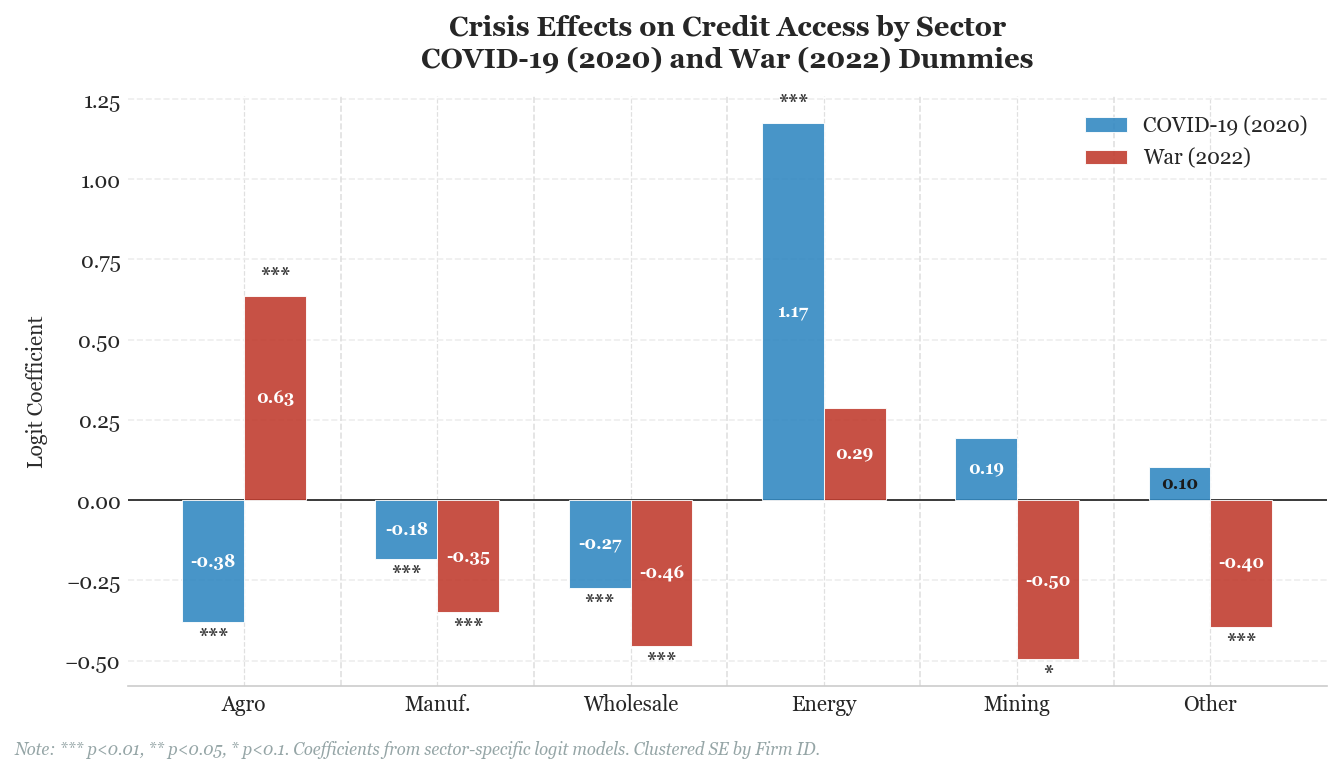

In [38]:

# CRISIS EFFECTS BY SECTOR — BAR CHART


sector_abbr = ['Agro', 'Manuf.', 'Wholesale', 'Energy', 'Mining', 'Other']
COLOR_COVID = '#2e86c1'
COLOR_WAR   = '#c0392b'

covid_coefs, covid_pvals = [], []
war_coefs,   war_pvals   = [], []

for sector in SECTOR_ORDER:
    model = results_sector[sector]['model']
    for coef_list, pval_list, var in [
        (covid_coefs, covid_pvals, 'COVID_Dummy'),
        (war_coefs,   war_pvals,   'War_Dummy'),
    ]:
        if var in model.params:
            coef_list.append(model.params[var])
            pval_list.append(model.pvalues[var])
        else:
            coef_list.append(0)
            pval_list.append(1)

x     = np.arange(len(SECTOR_ORDER))
width = 0.32

fig, ax = plt.subplots(figsize=(9, 5))

bars_covid = ax.bar(x - width/2, covid_coefs, width, color=COLOR_COVID, alpha=0.88,
                    label='COVID-19 (2020)', edgecolor='white', linewidth=0.5, zorder=3)
bars_war   = ax.bar(x + width/2, war_coefs,   width, color=COLOR_WAR,   alpha=0.88,
                    label='War (2022)',      edgecolor='white', linewidth=0.5, zorder=3)

def add_value_labels(bars, ax):
    for bar in bars:
        val = bar.get_height()
        if abs(val) < 0.02: continue
        color = 'white' if abs(val) > 0.15 else '#1a1a1a'
        ax.text(bar.get_x() + bar.get_width() / 2, val / 2,
                f'{val:.2f}', ha='center', va='center',
                fontsize=8, color=color, fontweight='bold', zorder=4)

def add_stars(bars, pvals, ax):
    for bar, pval in zip(bars, pvals):
        if np.isnan(pval): continue
        stars = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else ''))
        if not stars: continue
        y      = bar.get_height()
        offset = 0.03 if y >= 0 else -0.08
        ax.text(bar.get_x() + bar.get_width() / 2, y + offset, stars,
                ha='center', va='bottom', fontsize=10,
                color='#333333', fontweight='bold', zorder=4)

add_value_labels(bars_covid, ax)
add_value_labels(bars_war,   ax)
add_stars(bars_covid, covid_pvals, ax)
add_stars(bars_war,   war_pvals,   ax)

ax.axhline(y=0, color='#333333', linewidth=0.9, zorder=2)
for xi in x[:-1]:
    ax.axvline(xi + 0.5, color='#e0e0e0', linewidth=0.8, linestyle='--', zorder=1)

ax.set_xticks(x)
ax.set_xticklabels(sector_abbr, fontsize=11)
ax.set_ylabel('Logit Coefficient', fontsize=10, labelpad=8)
ax.tick_params(which='both', length=0, labelsize=10)
ax.yaxis.grid(True, color='#eeeeee', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'left']: ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.legend(fontsize=10, frameon=False, loc='upper right', bbox_to_anchor=(1, 1))
ax.set_title('Crisis Effects on Credit Access by Sector\n'
             'COVID-19 (2020) and War (2022) Dummies',
             fontsize=13, fontweight='bold', pad=14)

fig.text(0.01, -0.02,
         'Note: *** p<0.01, ** p<0.05, * p<0.1. '
         'Coefficients from sector-specific logit models. Clustered SE by Firm ID.',
         fontsize=8, color=COLORS['neutral'], style='italic')

plt.tight_layout()
plt.savefig('crisis_effects_by_sector.png', dpi=150)
plt.show()

## 13. ICR supplementary models — Energy and Mining

Adding Interest Coverage Ratio to sector-specific specifications for Energy and Mining, where ICR is theoretically relevant. Subset restricted to firms with positive financial expenses.

In [39]:
icr_sector_specs = {
    'Energy (ICR)': {
        'filter': (df['Sector Group'] == 'Energy') & df['ICR_EBIT_w_lag1'].notna(),
        'cols': ['log_Total_Assets_w_lag1', 'ROA_w_lag1', 'Quick_Ratio_w_lag1',
                 'NetDebt_to_EBITDA_w_lag1', 'WC_to_Assets_w_lag1', 'Firm Age', 'ICR_EBIT_w_lag1'],
    },
    'Mining (ICR)': {
        'filter': (df['Sector Group'] == 'Mining') & df['ICR_EBIT_w_lag1'].notna(),
        'cols': ['ROA_w_lag1', 'Quick_Ratio_w_lag1', 'NetDebt_to_EBITDA_w_lag1',
                 'Tangibility_w_lag1', 'Asset_Turnover_w_lag1', 'Firm Age', 'ICR_EBIT_w_lag1'],
    },
}

print('\nVIF RESULTS — ICR MODELS')
print('=' * 60)
for name, spec in icr_sector_specs.items():
    print(f'\n{name}')
    df_icr = df[spec['filter']].copy()
    temp   = df_icr[spec['cols']].dropna().astype(float)
    
    vif_data             = pd.DataFrame()
    vif_data['Variable'] = temp.columns
    vif_data['VIF']      = [variance_inflation_factor(temp.values, i) for i in range(temp.shape[1])]
    vif_data['Variable'] = vif_data['Variable'].str.replace('_w_lag1', '').str.replace('_lag1', '')
    vif_data['Status']   = vif_data['VIF'].apply(
        lambda x: 'HIGH >10' if x > 10 else ('WARN 5-10' if x > 5 else ('WARN 2-5' if x > 2 else 'ok <2'))
    )
    
    problems = vif_data[vif_data['VIF'] > 5]
    if len(problems) > 0:
        print('! PROBLEMS:')
        print(problems.round(2).to_string(index=False))
    else:
        print('ok All VIF < 5')
    print(vif_data.round(2).to_string(index=False))
    print(f'N observations: {len(temp):,}')


VIF RESULTS — ICR MODELS

Energy (ICR)
! PROBLEMS:
        Variable  VIF    Status
log_Total_Assets 5.59 WARN 5-10
         Variable  VIF    Status
 log_Total_Assets 5.59 WARN 5-10
              ROA 1.68     ok <2
      Quick_Ratio 1.15     ok <2
NetDebt_to_EBITDA 1.41     ok <2
     WC_to_Assets 1.98     ok <2
         Firm Age 4.23  WARN 2-5
         ICR_EBIT 1.40     ok <2
N observations: 649

Mining (ICR)
ok All VIF < 5
         Variable  VIF   Status
              ROA 1.43    ok <2
      Quick_Ratio 1.05    ok <2
NetDebt_to_EBITDA 1.16    ok <2
      Tangibility 2.78 WARN 2-5
   Asset_Turnover 2.35 WARN 2-5
         Firm Age 3.38 WARN 2-5
         ICR_EBIT 1.45    ok <2
N observations: 747


In [40]:
results_icr_sector = {}
print('RUNNING ICR SECTOR MODELS')
print('=' * 60)

for name, spec in icr_sector_specs.items():
    print(f'\n{name}')
    model, n_obs = run_sector_model(spec['cols'], spec['filter'])
    if model:
        results_icr_sector[name] = {'model': model, 'n_obs': n_obs}
        mcf = 1 - model.llf / model.llnull
        auc = roc_auc_score(model.model.endog, model.predict())
        print(f'  N={n_obs:,}  McF={mcf:.4f}  AUC={auc:.4f}')

# Comparison table
icr_all_vars = []
for spec in icr_sector_specs.values():
    for c in spec['cols']:
        if c not in icr_all_vars: icr_all_vars.append(c)
for v in ['COVID_Dummy', 'War_Dummy', 'Frontline_2014', 'Frontline_2022']:
    if v not in icr_all_vars: icr_all_vars.append(v)

def fmt_icr(model, var):
    if var not in model.params: return f"{'—':>20}"
    coef = model.params[var]
    pval = model.pvalues[var]
    sig  = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else ''))
    return f"{coef:>16.4f}{sig:>4}"

print('\nICR MODELS — COEFFICIENTS COMPARISON')
print('=' * 75)
print(f"{'Variable':<30} {'Energy (ICR)':>20} {'Mining (ICR)':>20}")
print('-' * 75)

for group_label, var_list in [
    ('Financial Indicators', [v for v in icr_all_vars
                              if v not in ['COVID_Dummy', 'War_Dummy', 'Frontline_2014', 'Frontline_2022']]),
    ('Crisis Controls',   ['COVID_Dummy', 'War_Dummy']),
    ('Regional Controls', ['Frontline_2014', 'Frontline_2022']),
]:
    print(f'\n--- {group_label} ---')
    for var in var_list:
        clean = var.replace('_w_lag1', '').replace('_lag1', '')
        row   = f"{clean:<30}"
        for name in icr_sector_specs.keys():
            row += fmt_icr(results_icr_sector[name]['model'], var) if name in results_icr_sector else f"{'—':>20}"
        print(row)

print('\n' + '-' * 75)
for stat_name, func in [
    ('McFadden R2', lambda m: f"{1 - m.llf/m.llnull:>20.4f}"),
    ('AUC',         lambda m: f"{roc_auc_score(m.model.endog, m.predict()):>20.4f}"),
    ('N obs',       lambda m: f"{int(m.nobs):>20,}"),
]:
    row = f"{stat_name:<30}"
    for name in icr_sector_specs.keys():
        row += func(results_icr_sector[name]['model']) if name in results_icr_sector else f"{'—':>20}"
    print(row)

print('\nNote: *** p<0.01, ** p<0.05, * p<0.1')
print('Base specification = sectoral model + ICR_EBIT.')
print('ICR subset: firms with positive financial expenses only.')
print('Selection bias present — interpret with caution.')
print('Clustered SE by Firm ID. Crisis dummies and Frontline included.')

RUNNING ICR SECTOR MODELS

Energy (ICR)
  N=630  McF=0.1316  AUC=0.7375

Mining (ICR)
  N=729  McF=0.0725  AUC=0.7078

ICR MODELS — COEFFICIENTS COMPARISON
Variable                               Energy (ICR)         Mining (ICR)
---------------------------------------------------------------------------

--- Financial Indicators ---
log_Total_Assets                        0.2270  **                   —
ROA                                     0.8140              0.7359    
Quick_Ratio                             0.0070              0.0174    
NetDebt_to_EBITDA                       0.5200 ***          0.4613 ***
WC_to_Assets                            0.6315  **                   —
Firm Age                               -0.0211             -0.0117    
ICR_EBIT                               -0.0034   *         -0.0030    
Tangibility                                      —          0.9238   *
Asset_Turnover                                   —          0.5121 ***

--- Crisis Controls ---
C

/opt/homebrew/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [41]:
# Save full dataframe with all winsorised indicators and lagged variables
cols_to_save = (
    ['Firm ID', 'Year', 'Region', 'Sector', 'Sector Group', 'Firm Status', 'Firm Age',
     'Total Debt', 'Total_Debt_lag1']
    + ['Y1_Has_Credit', 'Y2_Active_Credit_User', 'Y3_Increasing_Credit']
    + ['Frontline_2014', 'Frontline_2022']
    + [c for c in df.columns if c.endswith('_w')]
    + [c for c in df.columns if c.endswith('_lag1')]
)
cols_to_save = list(dict.fromkeys([c for c in cols_to_save if c in df.columns]))

df[cols_to_save].to_csv('df_with_indicators.csv', sep=';', encoding='utf-8', index=False)
print(f'Saved df_with_indicators.csv — shape: {df[cols_to_save].shape}')

Saved df_with_indicators.csv — shape: (81062, 54)
